# Total Spend Prediction — Regression Modeling

This notebook implements and compares a broad set of regression models to predict **TotalSpend**. Rather than focusing on a single modeling approach, the analysis follows a structured progression across multiple model families in order to evaluate different assumptions, levels of complexity, and inductive biases.

In total, **21 regression models** are trained and evaluated. These models are not random variants, but are intentionally grouped into coherent categories, each serving a specific analytical purpose. Some models act as simple baselines, others explore non-linear feature interactions, and more advanced ensemble methods are included to assess potential performance gains.

The modeling workflow is learning-oriented and exploratory by design. While not all models are intended for final deployment, each contributes to understanding the trade-offs between interpretability, flexibility, and generalization performance. All preprocessing steps are applied in a leakage-safe manner, with parameters fitted exclusively on the training data.

The evaluated models are organized into the following categories:

---

## 1. Linear and Regularized Linear Models (Models 1–6)

This group establishes baseline performance and emphasizes interpretability. It includes ordinary least squares regression and regularized variants designed to address multicollinearity and reduce model complexity.

- Baseline linear regression with different feature sets  
- Ridge regression for coefficient shrinkage  
- Lasso-based models for feature selection and sparsity  
- Linear regression trained on Lasso-selected features  

These models provide a reference point for assessing the added value of more complex approaches.

---

## 2. Polynomial Regression Models (Models 7–11)

Polynomial models extend linear regression by incorporating second-degree feature interactions. Both full and regularized variants are explored to balance expressive power and overfitting risk.

- Polynomial linear regression (degree 2)  
- Polynomial Ridge and Lasso models  
- Feature-selected polynomial models  

This group evaluates whether non-linear relationships substantially improve predictive performance.

---

## 3. Decision Tree Models (Models 12–15)

Single regression trees are used to capture complex non-linear patterns without explicit feature transformations.

- Fully grown regression tree (overfitting reference)  
- Hyperparameter-tuned regression tree  
- Cost-complexity pruned trees  

These models illustrate the trade-off between model flexibility and generalization.

---

## 4. Ensemble Tree-Based Models (Models 16–19)

Ensemble methods combine multiple decision trees to improve robustness and predictive accuracy.

- Random Forest (baseline and tuned)  
- Gradient Boosting regression  
- Tuned XGBoost regressor  

These models represent the most flexible and high-performing approaches evaluated in this notebook.

---

## 5. Kernel-Based Model (Model 20-21)

Support Vector Regression (SVR) with an RBF kernel is included as a distance-based, non-linear modeling alternative.

- SVR trained on a reduced feature set selected via Lasso  

This model provides a contrast to tree-based ensembles and polynomial approaches.

---

Overall, the model comparison highlights how predictive performance evolves as model complexity increases, and which modeling strategies offer the best balance between accuracy and generalization for TotalSpend prediction.


## 2. Technical Setup and Utilities

### 2.1 Imports

In [133]:
# ============================================================
# 📦 Core Scientific Stack
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# 📊 Visualization
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# ============================================================
# 📐 Statistics & Statistical Modeling
# ============================================================
import scipy.stats as stats
import statsmodels.api as sm

# ============================================================
# 🤖 Machine Learning — Core Utilities
# ============================================================
from sklearn.model_selection import (KFold, cross_val_score, GridSearchCV, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, PolynomialFeatures)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# ============================================================
# 🧱 Preprocessing & Pipelines
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# ============================================================
# 📈 Linear & Regularized Models
# ============================================================
from sklearn.linear_model import (LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV)

# ============================================================
# 🌳 Tree-Based Models
# ============================================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor)

# ============================================================
# 🌊 Kernel-Based Models
# ============================================================
from sklearn.svm import SVR

# ============================================================
# 🚀 Gradient Boosting (External)
# ============================================================
from xgboost import XGBRegressor

# ============================================================
# 🚨 Anomaly Detection (used in EDA / preprocessing)
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# ============================================================
# 🛠 Utilities & Configuration
# ============================================================
import os
import re
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 🎨 Project Styling
# ============================================================
MAIN_COLOR = "#B388EB"


### 2.2 Model Result Logging

In [134]:
# ============================================
# 📊 Regression Model Logger — Behavioral
# ============================================

behavioral_log = []

def log_behavioral_model(
    name,
    r2_train,
    r2_test,
    mse_train,
    mse_test,
    r2_cv=None,
    feature_count=None,
    notes=None
):
    global behavioral_log

    behavioral_log.append({
        "Model": name,
        "R²_train": round(r2_train, 3),
        "R²_test": round(r2_test, 3),
        "R²_CV": round(r2_cv, 3) if r2_cv is not None else None,
        "MSE_train": round(mse_train, 2),
        "MSE_test": round(mse_test, 2),
        "Feature_count": feature_count,
        "Notes": notes
    })


def get_behavioral_summary(sort_by="R²_test", ascending=False):
    df = pd.DataFrame(behavioral_log)
    if not df.empty and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending, ignore_index=True)
    return df


In [135]:
# ============================================
# 📊 Regression Model Logger — Profile-only
# ============================================

profile_log = []

def log_profile_model(
    name,
    r2_train,
    r2_test,
    mse_train,
    mse_test,
    r2_cv=None,
    feature_count=None,
    notes=None
):
    global profile_log

    profile_log.append({
        "Model": name,
        "R²_train": round(r2_train, 3),
        "R²_test": round(r2_test, 3),
        "R²_CV": round(r2_cv, 3) if r2_cv is not None else None,
        "MSE_train": round(mse_train, 2),
        "MSE_test": round(mse_test, 2),
        "Feature_count": feature_count,
        "Notes": notes
    })


def get_profile_summary(sort_by="R²_test", ascending=False):
    df = pd.DataFrame(profile_log)
    if not df.empty and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending, ignore_index=True)
    return df


 ### 2.3 IQR-Based Outlier Handling Utilities

In [136]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        # Ensure DataFrame for column-wise operations
        X = pd.DataFrame(X)

        # Store feature names for later use
        self.feature_names_in_ = X.columns.to_numpy()

        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1

        self.lower_bounds_ = q1 - self.k * iqr
        self.upper_bounds_ = q3 + self.k * iqr

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_).copy()

        for col in X.columns:
            X[col] = X[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )

        return X

    def get_feature_names_out(self, input_features=None):
        # sklearn-compatible feature name passthrough
        if input_features is not None:
            return np.array(input_features)
        return self.feature_names_in_


## 3. Data Preparation and Pipeline-Based Preprocessing

### 3.1 Load Raw Data

In [137]:
# Load raw marketing campaign dataset
df = pd.read_csv('Data/marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### 3.2 Basic Data Cleaning

Only minimal data cleaning is performed at this stage, including
type corrections (e.g. date fields).

A more extensive exploratory data analysis (EDA) was previously conducted
on the full dataset and is documented in a separate notebook
([eda.ipynb](eda.ipynb)).
Insights from that analysis informed feature selection and modeling decisions,
but the analysis itself is not repeated here.

In [138]:
# ----------------------------------
# 1.2 Basic Data Cleaning
# ----------------------------------

# Convert customer registration date to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)


### 3.3 Train / Test Split

In [139]:
# ----------------------------------
# 3.3 Train / Test Split
# ----------------------------------

from sklearn.model_selection import train_test_split

# Feature matrix (raw features only)
X = df.copy()

# Perform train / test split
X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=1234
)

# Sanity check
X_train.shape, X_test.shape


((1792, 29), (448, 29))

### 3.4 Target Construction (TotalSpend)

The regression target **TotalSpend** is not available in the raw dataset and is
constructed explicitly as the sum of customer spending across all product
categories.

Target construction is performed **after the train / test split** and **outside
of any preprocessing pipelines** to ensure a clear separation between target
definition and feature engineering.

No transformation is applied to the target at this stage.


In [140]:
# ----------------------------------
# 3.4 Target Construction
# ----------------------------------

# Spending columns used to define the target
spend_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Construct target for train and test sets
y_train = X_train[spend_cols].sum(axis=1)
y_test = X_test[spend_cols].sum(axis=1)

# Sanity check
y_train.shape, y_test.shape


((1792,), (448,))

### 3.5 Deterministic Feature Construction

At this stage, deterministic (rule-based) features are constructed using a
custom transformer. These features do not require learning from the data and
can be safely applied after the train / test split.

The transformer encapsulates domain-driven feature engineering logic (e.g.
temporal, demographic, household, and campaign-related features) and is
designed to be fully reusable and pipeline-compatible.

In [141]:
# ----------------------------------
# 3.5 Deterministic Feature Construction
# ----------------------------------

from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DeterministicFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Custom transformer for deterministic, rule-based feature construction.
    Leakage-safe: no target information is used.
    """

    def fit(self, X, y=None):
        # Reference points derived from training data only
        self.reference_year_ = X["Dt_Customer"].dt.year.max()
        self.reference_date_ = X["Dt_Customer"].max()
        return self

    def transform(self, X):
        X_ = X.copy()

        # ------------------
        # Temporal features
        # ------------------
        X_["Age"] = self.reference_year_ - X_["Year_Birth"]

        X_["Tenure_Days"] = (self.reference_date_ - X_["Dt_Customer"]).dt.days
        X_["Tenure_Months"] = (X_["Tenure_Days"] / 30).round().astype(int)

        # ------------------
        # Household & demographic
        # ------------------
        X_["Marital_Status"] = X_["Marital_Status"].replace(
            ['Alone', 'Absurd', 'YOLO'], 'Other'
        )

        X_["HasChildren"] = (
            (X_["Kidhome"] + X_["Teenhome"]) > 0
        ).astype(int)

        X_["FamilySize"] = (
            X_["Marital_Status"].isin(['Married', 'Together']).astype(int)
            + 1
            + X_["Kidhome"]
            + X_["Teenhome"]
        )

        # ------------------
        # Education
        # ------------------
        education_map = {
            'Basic': 1,
            '2n Cycle': 2,
            'Graduation': 3,
            'Master': 4,
            'PhD': 5
        }

        X_["Education_Level"] = X_["Education"].map(education_map)

        X_["Education_Level_Grouped"] = pd.cut(
            X_["Education_Level"],
            bins=[0, 2, 4, 5],
            labels=["Low", "Medium", "High"]
        )

        # ------------------
        # Purchase behavior
        # ------------------
        purchase_cols = [
            'NumWebPurchases',
            'NumCatalogPurchases',
            'NumStorePurchases'
        ]
        X_["TotalPurchases"] = X_[purchase_cols].sum(axis=1)

        # ------------------
        # Campaign behavior
        # ------------------
        accepted_cols = [
            'AcceptedCmp1',
            'AcceptedCmp2',
            'AcceptedCmp3',
            'AcceptedCmp4',
            'AcceptedCmp5'
        ]
        X_["TotalAccepted"] = X_[accepted_cols].sum(axis=1)

        return X_


### 3.6 Feature Group Definition

For the regression task, features are grouped based on the **actual preprocessing
strategy applied to each variable** (e.g. capping, scaling, or encoding).

This grouping reflects prior EDA decisions and is independent of the target
transformation. The regression target will be log-transformed later within
model-specific pipelines.

In [142]:
# ----------------------------------
# 3.6 Feature Group Definition
# ----------------------------------

# Numerical features with missing value handling and IQR-based capping
numeric_capped_cols = [
    'Income',
    'Age'
]

# Numerical features requiring scaling only (no log, no capping)
numeric_scaled_cols = [
    'Tenure_Days',
    'Tenure_Months',
    'Recency'
]

# Count-based numerical features (kept on original scale or lightly scaled)
numeric_count_cols = [
    'Kidhome',
    'Teenhome',
    'FamilySize',
    'TotalPurchases',
    'TotalAccepted'
]

# Binary features (already encoded as 0/1)
binary_cols = [
    'HasChildren',
    'Complain'
]

# Categorical features
categorical_cols = [
    'Education',
    'Education_Level_Grouped',
    'Marital_Status'
]

# Campaign indicators (binary, passthrough or scaled if needed)
campaign_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response'
]


### 3.7 Numeric and Categorical Preprocessing Pipelines

Based on the predefined feature groups, dedicated preprocessing pipelines are
constructed for numerical and categorical variables.

Each pipeline applies only the transformations required for its corresponding
feature group (e.g. missing value handling, IQR-based capping, scaling, or
encoding). All preprocessing steps are designed to be leakage-safe and
pipeline-compatible.


In [143]:
# ----------------------------------
# 3.6 Numeric and Categorical Preprocessing Pipelines
# ----------------------------------

# ---- Numeric pipelines ----

# Numeric features with missing values + IQR-based capping + scaling
numeric_capped_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("scaler", StandardScaler())
])

# Numeric features requiring scaling only
numeric_scaled_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Count-based numeric features (light scaling, no capping)
numeric_count_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Binary features (already encoded as 0/1, passed through)
binary_pipeline = Pipeline(steps=[
    ("passthrough", "passthrough")
])

# ---- Categorical pipeline ----

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])


### 3.8 ColumnTransformer (Final Preprocessor)

All preprocessing pipelines are combined into a single `ColumnTransformer`,
which serves as the final, model-agnostic preprocessing step.

This transformer applies the appropriate preprocessing pipeline to each
feature group and ensures a clean separation between feature engineering and
modeling. The resulting preprocessor can be reused consistently across
different regression models.

In [144]:
# ----------------------------------
# 3.8 ColumnTransformer (Final Preprocessor)
# ----------------------------------

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        # Numeric features with imputation + IQR capping + scaling
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),

        # Numeric features with scaling only
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),

        # Count-based numeric features
        ("num_count", numeric_count_pipeline, numeric_count_cols),

        # Binary features (passthrough)
        ("binary", "passthrough", binary_cols),

        # Categorical features
        ("cat", categorical_pipeline, categorical_cols),

        # Campaign indicators
        ("campaign", "passthrough", campaign_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [145]:
preprocessor

,transformers,"[('num_capped', ...), ('num_scaled', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 4. Baseline Regression Models

### Model 1 — Linear Regression (Baseline)

This model is evaluated under two feature scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)


#### 🔹 Variant A — Profile + Behavioral feature set

In [146]:
# ============================================================
# Model 1 — Linear Regression
# Variant A: Behavioral feature set (Clean)
# ============================================================

# ------------------------------------------------------------
# Variant A Feature Groups (CLEAN — one representation per concept)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]


# ------------------------------------------------------------
# Variant A Preprocessor
# ------------------------------------------------------------

preprocessor_m1a = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m1a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m1a),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m1a,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m1a.fit(X_train, y_train)

y_train_pred = pipe_lr_m1a.predict(X_train)
y_test_pred  = pipe_lr_m1a.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m1a.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 1 — Linear Regression(Baseline)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_test=mse_test,
    mse_train=mse_train,
    feature_count=feature_count,
    notes=(
        "Behavioral feature set with one representation per concept "
        "(counts for children and purchases, aggregated campaign response). "
        "No target transformation applied."
    )
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 1 — Linear Regression(Baseline)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 1 — Linear Regression(Baseline)
R² test : 0.830
R² train: 0.829
R² CV   : 0.819


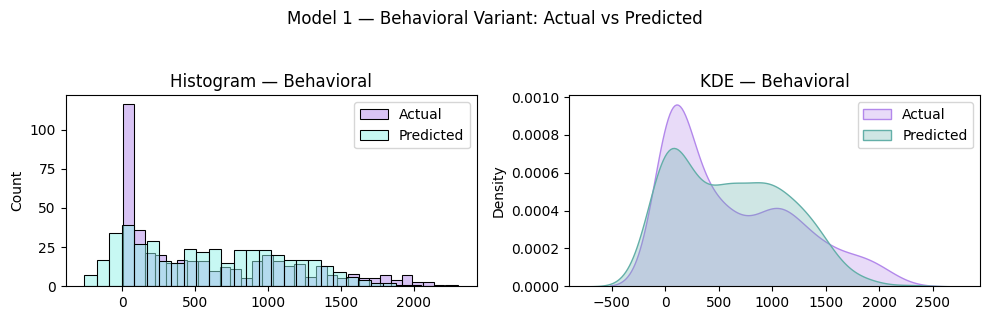

In [147]:
# ============================================================
# Model 1 — Behavioral Variant
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Histogram
sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)
sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9FF",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Histogram — Behavioral")
axes[0].legend()

# KDE
sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8FF",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("KDE — Behavioral")
axes[1].legend()

plt.suptitle("Model 1 — Behavioral Variant: Actual vs Predicted", y=1.05)
plt.tight_layout()
plt.show()


#### 🔹 Variant B — Profile-only feature set

In [148]:
# ============================================================
# Model 1 — Linear Regression
# Variant B: Customer profile only (Refactored)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Variant B Feature Groups (Profile-only)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Variant B Preprocessor
# ------------------------------------------------------------

preprocessor_m1b = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m1b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m1b),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m1b,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m1b.fit(X_train, y_train)

y_train_pred = pipe_lr_m1b.predict(X_train)
y_test_pred  = pipe_lr_m1b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m1b.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 1 — Linear Regression(Baseline)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_test=mse_test,
    mse_train=mse_train,
    feature_count=feature_count,
    notes="Customer profile features only (income, age, household, education)"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 1 — Linear Regression(Baseline)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 1 — Linear Regression(Baseline)
R² test : 0.686
R² train: 0.707
R² CV   : 0.701


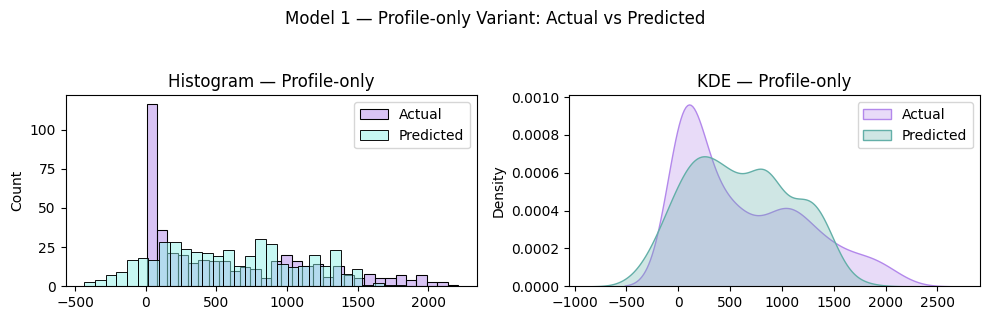

In [149]:
# ============================================================
# Model 1 — Profile-only Variant
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Histogram
sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)
sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9FF",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Histogram — Profile-only")
axes[0].legend()

# KDE
sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8FF",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("KDE — Profile-only")
axes[1].legend()

plt.suptitle("Model 1 — Profile-only Variant: Actual vs Predicted", y=1.05)
plt.tight_layout()
plt.show()


### Model 2 — Linear Regression (EDA-based Features)

This model uses a reduced set of features selected based on EDA insights.
It is evaluated under two scenarios:
- Behavioral feature set (EDA-based upper-bound benchmark)
- Customer profile feature set (EDA-based realistic scenario)

#### 🔹 Variant A — Profile + Behavioral feature set

In [150]:
# ============================================================
# Model 2 — Linear Regression
# Behavioral variant (EDA-based features)
# ============================================================

# ------------------------------------------------------------
# Feature groups (EDA-based, CLEAN)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days"
]

numeric_count_cols = [
    "Kidhome",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebPurchases",
    "NumWebVisitsMonth"
]

categorical_cols = [
    "Education",
    "Marital_Status",
    "AcceptedCmp1",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

# ------------------------------------------------------------
# Preprocessor (EDA-based)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lr", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr.fit(X_train, y_train)

y_train_pred = pipe_lr.predict(X_train)
y_test_pred  = pipe_lr.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 2 — Linear Regression (EDA-based features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="EDA-based behavioral feature selection"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 2 — Linear Regression variant (EDA-based features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 2 — Linear Regression variant (EDA-based features)
R² test : 0.821
R² train: 0.818
R² CV   : 0.809


#### 🔹 Variant B — Profile-only feature set

In [151]:
# ============================================================
# Model 2 — Linear Regression
# Profile-only variant (EDA-based features)
# ============================================================

# ------------------------------------------------------------
# Feature groups (Profile-only, EDA-based)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    #"Teenhome" #intentionally excluded (EDA decision)
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lr", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr.fit(X_train, y_train)

y_train_pred = pipe_lr.predict(X_train)
y_test_pred  = pipe_lr.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_profile_model(
    name="Model 2 — Linear Regression (EDA-based features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="EDA-based profile feature selection"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 2 — Linear Regression (EDA-based features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 2 — Linear Regression (EDA-based features)
R² test : 0.660
R² train: 0.685
R² CV   : 0.679


### Model 3 — Ridge Regression (Regularized Linear Model)

This model extends linear regression by applying L2 regularization (Ridge)
to mitigate multicollinearity and improve coefficient stability.

The model is evaluated under two feature scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)



#### 🔹 Variant A — Profile + Behavioral feature set


In [152]:
# ============================================================
# Model 3 — Ridge Regression
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (UNCHANGED — exactly as you defined)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (same groups, just organized)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Ridge model (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-3, 3, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=cv_inner,
    scoring="r2"
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_ridge = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("ridge", ridge)
])

# ------------------------------------------------------------
# Outer CV (evaluation)
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_ridge,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_ridge.fit(X_train, y_train)

y_train_pred = pipe_ridge.predict(X_train)
y_test_pred  = pipe_ridge.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust, pipeline-consistent)
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 3 — Ridge Regression",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Behavioral feature set with Ridge regularization (pipeline-based)"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 3 — Ridge Regression")
print(f"Best α  : {pipe_ridge.named_steps['ridge'].alpha_:.5f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 3 — Ridge Regression
Best α  : 25.59548
R² test : 0.831
R² train: 0.828
R² CV   : 0.820


#### 🔹 Variant B — Profile-only feature set

In [153]:
# ============================================================
# Model 3 — Ridge Regression
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (PROFILE-ONLY, same STRUCTURE as Variant A)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (group-based, Variant A–like)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Ridge model (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-3, 3, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=cv_inner,
    scoring="r2"
)

# ------------------------------------------------------------
# Pipeline (SAME STYLE as Variant A)
# ------------------------------------------------------------

pipe_ridge = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("ridge", ridge)
])

# ------------------------------------------------------------
# Outer CV
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_ridge,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_ridge.fit(X_train, y_train)

y_train_pred = pipe_ridge.predict(X_train)
y_test_pred  = pipe_ridge.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (pipeline-consistent)
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_profile_model(
    name="Model 3 — Ridge Regression",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Profile-only feature set with group-based preprocessing and Ridge regularization"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 3 — Ridge Regression")
print(f"Best α  : {pipe_ridge.named_steps['ridge'].alpha_:.5f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 3 — Ridge Regression
Best α  : 19.30698
R² test : 0.687
R² train: 0.706
R² CV   : 0.702


### Model 4 — Lasso Regression (Automatic Feature Selection)

This model applies L1 regularization (Lasso) to automatically select a sparse
set of informative features by shrinking less relevant coefficients to zero.

The model is evaluated under two feature scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)


#### 🔹 Variant A — Profile + Behavioral feature set

In [154]:
# ============================================================
# Model 4 — LassoCV
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (UNCHANGED CONCEPTUALLY, just organized)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (group-based, same as previous models)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

# ------------------------------------------------------------
# Lasso model (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-4, 1, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

lasso = LassoCV(
    alphas=alphas,
    cv=cv_inner,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lasso", lasso)
])

# ------------------------------------------------------------
# Outer CV
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso.fit(X_train, y_train)

y_train_pred = pipe_lasso.predict(X_train)
y_test_pred  = pipe_lasso.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO coefficients)
# ------------------------------------------------------------

feature_names = pipe_lasso.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso.named_steps["lasso"].coef_

selected = [
    (name, coef)
    for name, coef in zip(feature_names, coefs)
    if coef != 0
]

selected_sorted = sorted(
    selected, key=lambda x: abs(x[1]), reverse=True
)

n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 4 — LassoCV",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=n_selected,
    notes="Behavioral feature set with L1 regularization (group-based pipeline)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 4 — LassoCV")
print(f"Best α  : {pipe_lasso.named_steps['lasso'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected} / {len(feature_names)}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 4 — LassoCV
Best α  : 1.526418
R² test : 0.832
R² train: 0.828
R² CV   : 0.820

Selected features: 19 / 29
  campaign__AcceptedCmp5                         coef = +273.8161
  num_capped__Income                             coef = +211.2194
  num_count__NumCatalogPurchases                 coef = +175.1163
  num_count__NumStorePurchases                   coef = +100.3836
  campaign__AcceptedCmp1                         coef = +73.9290
  num_count__Teenhome                            coef = -70.2358
  campaign__AcceptedCmp4                         coef = +67.0299
  num_count__NumWebPurchases                     coef = +65.8118
  num_scaled__Tenure_Days                        coef = +50.3029
  num_count__Kidhome                             coef = -47.5253
  campaign__Response                             coef = +33.7256
  cat__Education_2n Cycle                        coef = -26.9896
  num_count__NumWebVisitsMonth                   coef = +14.7712
  num_scaled__Recency                 

#### 🔹 Variant B — Profile-only feature set

In [155]:
# ============================================================
# Model 4 — LassoCV
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (PROFILE-ONLY, group-based)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (same STRUCTURE as other models)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

# ------------------------------------------------------------
# LassoCV (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-4, 1, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

lasso = LassoCV(
    alphas=alphas,
    cv=cv_inner,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lasso", lasso)
])

# ------------------------------------------------------------
# Outer CV
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso.fit(X_train, y_train)

y_train_pred = pipe_lasso.predict(X_train)
y_test_pred  = pipe_lasso.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO, with REAL names)
# ------------------------------------------------------------

feature_names = pipe_lasso.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso.named_steps["lasso"].coef_

selected = [
    (name, coef)
    for name, coef in zip(feature_names, coefs)
    if coef != 0
]

selected_sorted = sorted(
    selected,
    key=lambda x: abs(x[1]),
    reverse=True
)

n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_profile_model(
    name="Model 4 — LassoCV",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=n_selected,
    notes="Profile-only feature set, group-based preprocessing, L1 regularization"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 4 — LassoCV")
print(f"Best α  : {pipe_lasso.named_steps['lasso'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected} / {len(feature_names)}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 4 — LassoCV
Best α  : 3.088844
R² test : 0.688
R² train: 0.705
R² CV   : 0.703

Selected features: 5 / 15
  num_capped__Income                             coef = +427.8227
  num_count__Kidhome                             coef = -118.3085
  num_count__Teenhome                            coef = -96.6519
  cat__Education_2n Cycle                        coef = -17.6722
  num_capped__Age                                coef = -6.1988


### Model 5 — Lasso Regression (Fixed Alpha)

This model applies L1 regularization with a fixed regularization strength (α),
selected based on the results of LassoCV.  
Fixing α allows for a more stable and interpretable sparse solution.

The model is evaluated under two feature scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)


#### 🔹 Variant A — Profile + Behavioral feature set

In [156]:
# ============================================================
# Model 5 — Lasso Regression (Fixed Alpha)
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (SAME as Model 4 Variant A)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (group-based)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

# ------------------------------------------------------------
# Fixed-alpha Lasso
# ------------------------------------------------------------

alpha_fixed = 13 # from LassoCV

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso_fixed = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lasso", lasso_fixed)
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso_fixed,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_fixed.fit(X_train, y_train)

y_train_pred = pipe_lasso_fixed.predict(X_train)
y_test_pred  = pipe_lasso_fixed.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO)
# ------------------------------------------------------------

feature_names = pipe_lasso_fixed.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso_fixed.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if c != 0]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 5 — Lasso Regression (Fixed Alpha)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=n_selected,
    notes="Behavioral features, fixed alpha from LassoCV (α = 1.526)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 5 — Lasso Regression (Fixed Alpha)")
print(f"Alpha fixed: {alpha_fixed:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 5 — Lasso Regression (Fixed Alpha)
Alpha fixed: 13.000000
R² test : 0.827
R² train: 0.816
R² CV   : 0.813

Selected features: 8
  num_capped__Income                             coef = +220.5518
  num_count__NumCatalogPurchases                 coef = +180.7578
  campaign__AcceptedCmp5                         coef = +156.6733
  num_count__NumStorePurchases                   coef = +92.3316
  num_count__NumWebPurchases                     coef = +67.7494
  num_count__Teenhome                            coef = -66.2470
  num_scaled__Tenure_Days                        coef = +45.9015
  num_count__Kidhome                             coef = -38.5573


##### 🔹 Coefficient Path — Variant A (Behavioral)

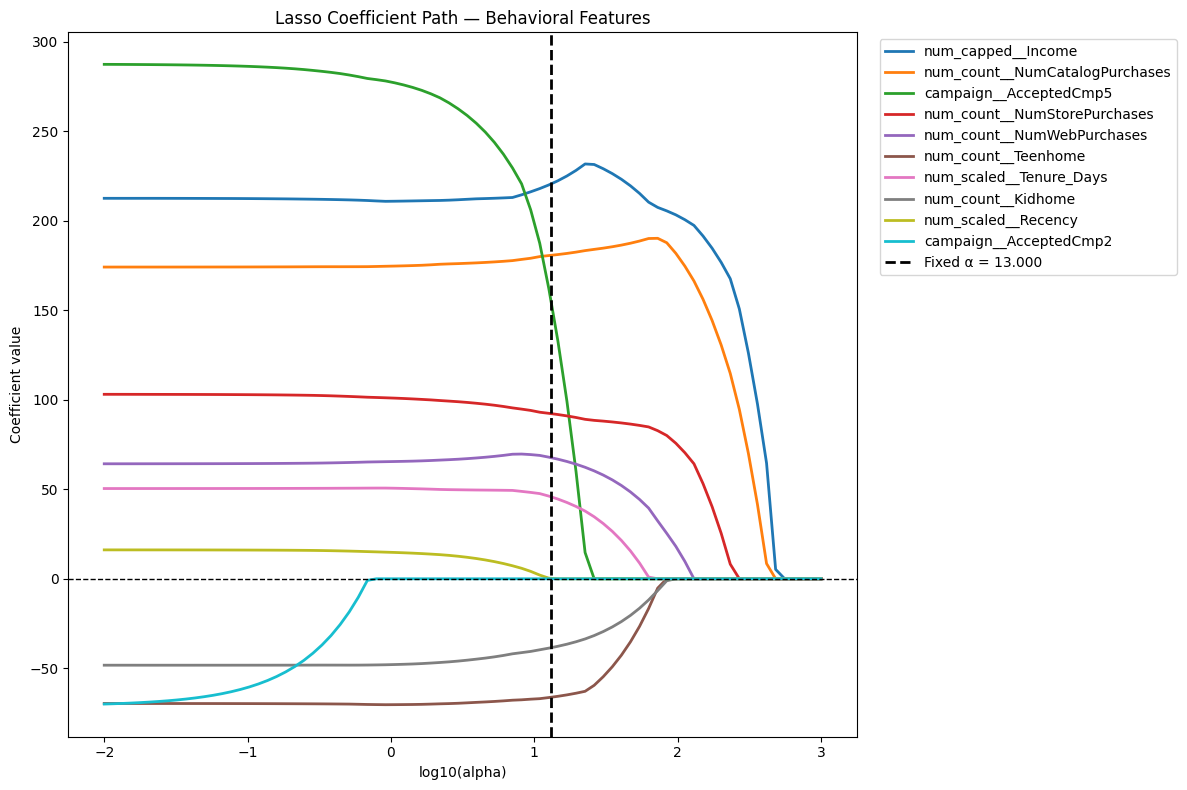

In [157]:
# ============================================================
# Lasso Coefficient Path — Variant A (Behavioral)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# ------------------------------------------------------------
# Prepare design matrix (USING SAME PIPELINE AS MODEL 5)
# ------------------------------------------------------------

X_train_prepared = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_names = preprocessor.get_feature_names_out()

# ------------------------------------------------------------
# Alpha grid (MUST cover fixed alpha ≈ 1.53)
# ------------------------------------------------------------

alphas = np.logspace(-2, 3, 80)   # up to 10 → safe

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=50000)
    lasso.fit(X_train_prepared, y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

# ------------------------------------------------------------
# Fixed alpha (from Model 5)
# ------------------------------------------------------------

alpha_fixed = 13  # same as in Model 5

idx_fixed = np.argmin(np.abs(alphas - alpha_fixed))
coef_at_fixed = coefs[idx_fixed]

# ------------------------------------------------------------
# Select top 10 features by |coef| at fixed alpha
# ------------------------------------------------------------

top_idx_sorted = np.argsort(np.abs(coef_at_fixed))[-10:][::-1]

# ------------------------------------------------------------
# Plot coefficient paths
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

for i in top_idx_sorted:
    plt.plot(
        np.log10(alphas),
        coefs[:, i],
        linewidth=2,
        label=feature_names[i]
    )

plt.axvline(
    np.log10(alpha_fixed),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Fixed α = {alpha_fixed:.3f}"
)

plt.axhline(y=0, color="black", linestyle="--", linewidth=1)

y_min = coefs[:, top_idx_sorted].min()
y_max = coefs[:, top_idx_sorted].max()
pad = 0.05 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Path — Behavioral Features")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### 🔹 Variant B — Profile-only feature set

In [158]:
# ============================================================
# Model 5 — Lasso Regression (Fixed Alpha)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (PROFILE-ONLY, consistent with other models)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (group-based)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

# ------------------------------------------------------------
# Fixed-alpha Lasso
# ------------------------------------------------------------

alpha_fixed = 10

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso_fixed = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lasso", lasso_fixed)
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso_fixed,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_fixed.fit(X_train, y_train)

y_train_pred = pipe_lasso_fixed.predict(X_train)
y_test_pred  = pipe_lasso_fixed.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO)
# ------------------------------------------------------------

feature_names = pipe_lasso_fixed.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso_fixed.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if c != 0]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_profile_model(
    name="Model 5 — Lasso Regression (Fixed Alpha)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=n_selected,
    notes="Profile-only features, fixed alpha = 3.5"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 5 — Lasso Regression (Fixed Alpha)")
print(f"Alpha fixed: {alpha_fixed}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 5 — Lasso Regression (Fixed Alpha)
Alpha fixed: 10
R² test : 0.687
R² train: 0.704
R² CV   : 0.703

Selected features: 3
  num_capped__Income                             coef = +422.8533
  num_count__Kidhome                             coef = -112.3349
  num_count__Teenhome                            coef = -91.4114


##### 🔹 Coefficient Path — Variant B (Profile-only)

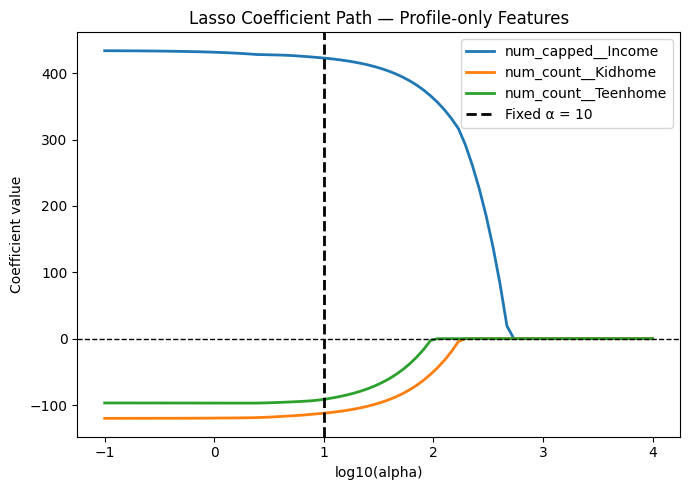

In [159]:
# ============================================================
# Lasso Coefficient Path — Variant B (Profile-only)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# ------------------------------------------------------------
# Prepare design matrix (USING SAME PIPELINE AS MODEL 5)
# ------------------------------------------------------------

X_train_prepared = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_names = preprocessor.get_feature_names_out()

# ------------------------------------------------------------
# Alpha grid (MUST include alpha = 3.5)
# ------------------------------------------------------------

alphas = np.logspace(-1, 4, 80)   # up to 10 → safe

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=50000)
    lasso.fit(X_train_prepared, y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

# ------------------------------------------------------------
# Fixed alpha (from Model 5 — Variant B)
# ------------------------------------------------------------

alpha_fixed = 10
idx_fixed = np.argmin(np.abs(alphas - alpha_fixed))
coef_at_fixed = coefs[idx_fixed]

# ------------------------------------------------------------
# Select non-zero features at fixed alpha
# (usually very few for profile-only)
# ------------------------------------------------------------

top_idx_sorted = np.argsort(np.abs(coef_at_fixed))[::-1]
active_idx = [i for i in top_idx_sorted if coef_at_fixed[i] != 0]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

for i in active_idx:
    plt.plot(
        np.log10(alphas),
        coefs[:, i],
        linewidth=2,
        label=feature_names[i]
    )

plt.axvline(
    np.log10(alpha_fixed),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Fixed α = {alpha_fixed}"
)

plt.axhline(y=0, color="black", linestyle="--", linewidth=1)

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Path — Profile-only Features")
plt.legend()
plt.tight_layout()
plt.show()


### Model 6 — Linear Regression (Lasso-selected Features)

This model retrains a linear regression using only the features selected
by Lasso with a fixed regularization strength (α = 0.03).

By removing regularization in the final step, this model evaluates whether
Lasso-selected features can achieve strong performance while improving
interpretability and coefficient stability.

The model is evaluated under two scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)


#### 🔹 Variant A — Profile + Behavioral feature set

In [160]:
# ============================================================
# Model 6 — Linear Regression
# Variant A: Top-8 Lasso-selected features (Clean, Group-based)
# ============================================================

# ------------------------------------------------------------
# Variant A Feature Groups
# (ONLY the 8 features selected by Lasso, alpha = 13)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income"          
]

numeric_scaled_cols = [
    "Tenure_Days"
]

numeric_count_cols = [
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebPurchases",
    "Teenhome",
    "Kidhome"
]

binary_cols = [
    "AcceptedCmp5"
]

# ------------------------------------------------------------
# Variant A Preprocessor
# ------------------------------------------------------------

preprocessor_m6 = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m6 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m6),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m6,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m6.fit(X_train, y_train)

y_train_pred = pipe_lr_m6.predict(X_train)
y_test_pred  = pipe_lr_m6.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m6.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]   # should be 8

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 6 — Linear Regression (Top-8 Lasso-selected)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_test=mse_test,
    mse_train=mse_train,
    feature_count=feature_count,
    notes=(
        "Linear regression on 8 features selected via Lasso (alpha = 13). "
        "Clean group-based preprocessing, one representation per concept."
    )
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 6 — Linear Regression (Top-8 Lasso-selected)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 6 — Linear Regression (Top-8 Lasso-selected)
R² test : 0.829
R² train: 0.823
R² CV   : 0.820


#### 🔹 Variant B — Profile-only feature set

In [161]:
# ============================================================
# Model 6 — Linear Regression (Lasso-selected features)
# Variant B: Profile-only feature set (Clean)
# ============================================================

# ------------------------------------------------------------
# Variant B Feature Groups (ONLY selected profile features)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

# ------------------------------------------------------------
# Variant B Preprocessor
# ------------------------------------------------------------

preprocessor_m6b = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m6b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m6b),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m6b,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m6b.fit(X_train, y_train)

y_train_pred = pipe_lr_m6b.predict(X_train)
y_test_pred  = pipe_lr_m6b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Coefficients (interpretable)
# ------------------------------------------------------------

coefs = pipe_lr_m6b.named_steps["regressor"].coef_

coef_table = sorted(
    zip(numeric_capped_cols + numeric_count_cols, coefs),
    key=lambda x: abs(x[1]),
    reverse=True
)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 6 — Linear Regression (Lasso-selected)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=len(coef_table),
    notes=(
        "Linear regression on profile-only features selected via Lasso. "
        "Includes Income and household size indicators only."
    )
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 6 — Linear Regression (Lasso-selected, Profile-only)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print("\nSelected coefficients (sorted by |coef|):")
for name, c in coef_table:
    print(f"{name:20s}  coef = {c:+.4f}")


Model 6 — Linear Regression (Lasso-selected, Profile-only)
R² test : 0.688
R² train: 0.705
R² CV   : 0.703

Selected coefficients (sorted by |coef|):
Income                coef = +429.6069
Kidhome               coef = -119.3048
Teenhome              coef = -101.9506


## 4. Polynomial Regression Models

Linear models assume additive and linear relationships between features and the target.
In this section, polynomial regression models are introduced to explicitly capture
second-order interactions and non-linear effects between predictors.

Polynomial features increase model flexibility by allowing interactions such as:
- Income × Tenure
- Age²
- Income × Age

However, this increased flexibility also raises the risk of overfitting.
Therefore, polynomial models are evaluated both in unregularized and regularized forms
(Ridge and Lasso) to control model complexity.

All polynomial models use degree = 2 and follow the same leakage-safe preprocessing
and evaluation framework as previous models.


### Model 7 — Polynomial Linear Regression (degree = 2)

#### 🔹 Variant A — Profile + Behavioral feature set

In [164]:
# ============================================================
# Model 7 — Polynomial Linear Regression (degree = 2)
# Variant A: Behavioral feature set (Pipeline-based)
# ============================================================

# ------------------------------------------------------------
# Variant A Feature Groups (SAME as other behavioral models)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Polynomial pipelines (ONLY numeric features)
# ------------------------------------------------------------

numeric_capped_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_scaled_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_count_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])


# ------------------------------------------------------------
# Variant A Preprocessor
# ------------------------------------------------------------

preprocessor_m7 = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_poly_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_poly_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_poly_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_poly_m7 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m7),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_poly_m7,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_poly_m7.fit(X_train, y_train)

y_train_pred = pipe_poly_m7.predict(X_train)
y_test_pred  = pipe_poly_m7.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust, post-preprocessing)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m7.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 7 — Polynomial Linear Regression (deg=2)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=(
        "Polynomial (degree=2) expansion applied to numeric features only. "
        "Binary, campaign, and categorical features kept linear."
    )
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 7 — Polynomial Linear Regression (deg=2)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Total features after preprocessing: {feature_count}")


Model 7 — Polynomial Linear Regression (deg=2)
R² test : 0.819
R² train: 0.859
R² CV   : 0.828
Total features after preprocessing: 63


#### Diagnostic plots — Model 7 (Variant A)

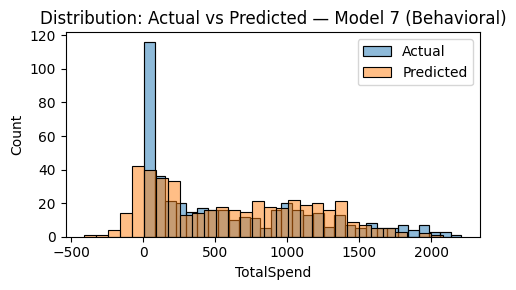

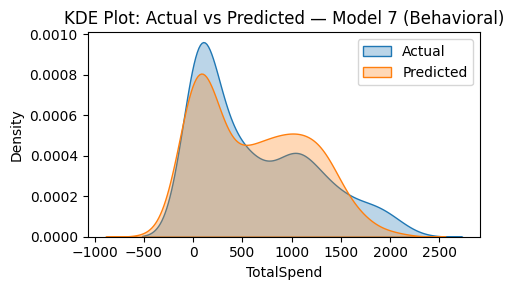

In [165]:
# ==========================================
# Diagnostic plots — Model 7 (Variant A)
# ==========================================

# --------------------------------------------------
# Histogram: Actual vs Predicted
# --------------------------------------------------

plt.figure(figsize=(5, 3))

sns.histplot(
    y_test,
    label="Actual",
    bins=30,
    alpha=0.5
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    bins=30,
    alpha=0.5
)

plt.title("Distribution: Actual vs Predicted — Model 7 (Behavioral)")
plt.xlabel("TotalSpend")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# KDE plot: Actual vs Predicted
# --------------------------------------------------

plt.figure(figsize=(5, 3))

sns.kdeplot(
    y_test,
    label="Actual",
    fill=True,
    alpha=0.3
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    fill=True,
    alpha=0.3
)

plt.title("KDE Plot: Actual vs Predicted — Model 7 (Behavioral)")
plt.xlabel("TotalSpend")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


#### 🔹 Variant B — Profile-only feature set

In [167]:
# ============================================================
# Model 7 — Polynomial Linear Regression (degree = 2)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Variant B Feature Groups (Profile-only)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Polynomial numeric pipelines (with imputation)
# ------------------------------------------------------------

numeric_capped_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_count_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

# ------------------------------------------------------------
# Variant B Preprocessor
# ------------------------------------------------------------

preprocessor_m7b = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_poly_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_poly_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_poly_m7b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m7b),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_poly_m7b,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_poly_m7b.fit(X_train, y_train)

y_train_pred = pipe_poly_m7b.predict(X_train)
y_test_pred  = pipe_poly_m7b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (post-preprocessing, robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m7b.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 7 — Polynomial Linear Regression (deg=2)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=(
        "Polynomial degree=2 applied to profile-only numeric features "
        "(Income, Age, household counts). Categorical features kept linear."
    )
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 7 — Polynomial Linear Regression (Variant B)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Total features after preprocessing: {feature_count}")


Model 7 — Polynomial Linear Regression (Variant B)
R² test : 0.699
R² train: 0.713
R² CV   : 0.705
Total features after preprocessing: 21


#### Diagnostic plots — Model 7 (Variant B)

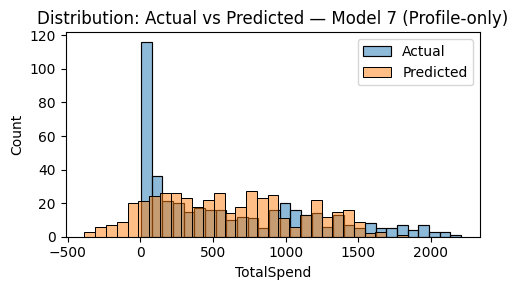

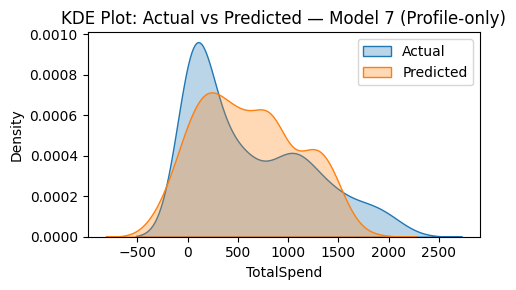

In [168]:
# ==========================================
# Diagnostic plots — Model 7 (Variant B)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Histogram: Actual vs Predicted
# --------------------------------------------------

plt.figure(figsize=(5, 3))

sns.histplot(
    y_test,
    label="Actual",
    bins=30,
    alpha=0.5
)

sns.histplot(
    y_test_pred,
    label="Predicted",
    bins=30,
    alpha=0.5
)

plt.title("Distribution: Actual vs Predicted — Model 7 (Profile-only)")
plt.xlabel("TotalSpend")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# KDE plot: Actual vs Predicted
# --------------------------------------------------

plt.figure(figsize=(5, 3))

sns.kdeplot(
    y_test,
    label="Actual",
    fill=True,
    alpha=0.3
)

sns.kdeplot(
    y_test_pred,
    label="Predicted",
    fill=True,
    alpha=0.3
)

plt.title("KDE Plot: Actual vs Predicted — Model 7 (Profile-only)")
plt.xlabel("TotalSpend")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


### Model 8 — Polynomial Ridge Regression (degree = 2)

#### 🔹 Variant A — Profile + Behavioral feature set

In [169]:
# ============================================================
# Model 8 — Polynomial Ridge Regression (degree = 2)
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Variant A Feature Groups (SAME as Models 1, 7)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Polynomial numeric pipelines (with imputation)
# ------------------------------------------------------------

numeric_capped_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_scaled_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_count_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

# ------------------------------------------------------------
# Variant A Preprocessor
# ------------------------------------------------------------

preprocessor_m8 = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_poly_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_poly_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_poly_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → RidgeCV
# ------------------------------------------------------------

alphas = np.logspace(-2, 2, 50)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=cv5,
    scoring="r2"
)

pipe_ridge_poly_m8 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m8),
    ("regressor", ridge_cv)
])

# ------------------------------------------------------------
# Cross-validation (outer, train only)
# ------------------------------------------------------------

r2_cv = cross_val_score(
    pipe_ridge_poly_m8,
    X_train,
    y_train,
    cv=cv5,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_ridge_poly_m8.fit(X_train, y_train)

y_train_pred = pipe_ridge_poly_m8.predict(X_train)
y_test_pred  = pipe_ridge_poly_m8.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (post-preprocessing, robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m8.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 8 — Polynomial Ridge Regression (deg=2)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=(
        "Polynomial degree=2 applied to numeric features only, "
        "with Ridge regularization to control overfitting."
    )
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 8 — Polynomial Ridge Regression (Variant A)")
print(f"Best α  : {pipe_ridge_poly_m8.named_steps['regressor'].alpha_:.4f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Total features after preprocessing: {feature_count}")


Model 8 — Polynomial Ridge Regression (Variant A)
Best α  : 15.2642
R² test : 0.825
R² train: 0.857
R² CV   : 0.838
Total features after preprocessing: 63


#### 🔹 Variant B — Profile-only feature set

In [170]:
# ============================================================
# Model 8 — Polynomial Ridge Regression (degree = 2)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Variant B Feature Groups (Profile-only)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Polynomial numeric pipelines (with imputation)
# ------------------------------------------------------------

numeric_capped_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_count_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

# ------------------------------------------------------------
# Variant B Preprocessor
# ------------------------------------------------------------

preprocessor_m8b = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_poly_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_poly_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → RidgeCV
# ------------------------------------------------------------

alphas = np.logspace(-2, 2, 50)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=cv5,
    scoring="r2"
)

pipe_ridge_poly_m8b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m8b),
    ("regressor", ridge_cv)
])

# ------------------------------------------------------------
# Cross-validation (outer, train only)
# ------------------------------------------------------------

r2_cv = cross_val_score(
    pipe_ridge_poly_m8b,
    X_train,
    y_train,
    cv=cv5,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_ridge_poly_m8b.fit(X_train, y_train)

y_train_pred = pipe_ridge_poly_m8b.predict(X_train)
y_test_pred  = pipe_ridge_poly_m8b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (post-preprocessing, robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m8b.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 8 — Polynomial Ridge Regression (deg=2)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=(
        "Polynomial degree=2 applied to profile-only numeric features, "
        "with Ridge regularization to control overfitting."
    )
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 8 — Polynomial Ridge Regression (Variant B)")
print(f"Best α  : {pipe_ridge_poly_m8b.named_steps['regressor'].alpha_:.4f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Total features after preprocessing: {feature_count}")


Model 8 — Polynomial Ridge Regression (Variant B)
Best α  : 8.6851
R² test : 0.701
R² train: 0.713
R² CV   : 0.705
Total features after preprocessing: 21


### Model 9 — Polynomial LassoCV (degree = 2)

#### 🔹 Variant A — Profile + Behavioral feature set

In [176]:
# ============================================================
# Model 9 — Polynomial LassoCV (degree = 2)
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Variant A Feature Groups (SAME as Models 7 & 8)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Polynomial numeric pipelines (with imputation)
# ------------------------------------------------------------

numeric_capped_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_scaled_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_count_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

# ------------------------------------------------------------
# Variant A Preprocessor
# ------------------------------------------------------------

preprocessor_m9 = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_poly_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_poly_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_poly_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True   # needed for feature inspection
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → LassoCV
# ------------------------------------------------------------

alphas = np.logspace(-4, 1, 40)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=cv5,
    max_iter=100000,
    random_state=42
)

pipe_lasso_poly_m9 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m9),
    ("regressor", lasso_cv)
])

# ------------------------------------------------------------
# Cross-validation (outer, train only)
# ------------------------------------------------------------

r2_cv = cross_val_score(
    pipe_lasso_poly_m9,
    X_train,
    y_train,
    cv=cv5,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_poly_m9.fit(X_train, y_train)

y_train_pred = pipe_lasso_poly_m9.predict(X_train)
y_test_pred  = pipe_lasso_poly_m9.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO coefficients)
# ------------------------------------------------------------

feature_names = pipe_lasso_poly_m9.named_steps["preprocessor"].get_feature_names_out()
coefs = pipe_lasso_poly_m9.named_steps["regressor"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if abs(c) > 1e-8]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)

feature_count = len(selected)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 9 — Polynomial LassoCV (deg=2)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=(
        "Polynomial degree=2 applied to numeric features, "
        "with L1 regularization (LassoCV) for automatic feature selection."
    )
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 9 — Polynomial LassoCV (Variant A)")
print(f"Best α  : {pipe_lasso_poly_m9.named_steps['regressor'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nTotal features after preprocessing: {len(feature_names)}")
print(f"Selected (non-zero) features: {feature_count}")

print("\nTop selected features:")
for name, coef in selected_sorted[:15]:
    print(f"{name:55s}  coef = {coef:+.4f}")


Model 9 — Polynomial LassoCV (Variant A)
Best α  : 1.701254
R² test : 0.823
R² train: 0.854
R² CV   : 0.839

Total features after preprocessing: 63
Selected (non-zero) features: 35

Top selected features:
num_count__NumCatalogPurchases                           coef = +461.2673
campaign__AcceptedCmp5                                   coef = +240.2380
num_count__NumCatalogPurchases^2                         coef = -180.1616
num_count__NumCatalogPurchases NumStorePurchases         coef = -143.5494
num_capped__Income^2                                     coef = +141.8010
num_count__NumStorePurchases                             coef = +124.7910
num_count__Teenhome                                      coef = -110.0797
num_count__Teenhome NumStorePurchases                    coef = -57.1546
num_count__NumStorePurchases NumWebVisitsMonth           coef = +56.5103
num_capped__Income                                       coef = +48.7020
campaign__AcceptedCmp4                                   c

#### 🔹 Variant B — Profile-only feature set

In [178]:
# ============================================================
# Model 9 — Polynomial LassoCV (degree = 2)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (Profile-only)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Pipelines
# ------------------------------------------------------------

numeric_capped_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_count_poly_pipeline = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

# ------------------------------------------------------------
# Preprocessor
# ------------------------------------------------------------

preprocessor_m9b = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_poly_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_poly_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# LassoCV
# ------------------------------------------------------------

alphas = np.logspace(-4, 1, 40)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=cv5,
    max_iter=100000,
    random_state=42
)

pipe_lasso_poly_m9b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m9b),
    ("lasso", lasso_cv)
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------

r2_cv = cross_val_score(
    pipe_lasso_poly_m9b,
    X_train,
    y_train,
    cv=cv5,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_poly_m9b.fit(X_train, y_train)

y_train_pred = pipe_lasso_poly_m9b.predict(X_train)
y_test_pred  = pipe_lasso_poly_m9b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO)
# ------------------------------------------------------------

feature_names = pipe_lasso_poly_m9b.named_steps["preprocessor"].get_feature_names_out()
coefs = pipe_lasso_poly_m9b.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if abs(c) > 1e-8]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
feature_count = len(selected_sorted)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 9 — Polynomial LassoCV",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Polynomial deg=2 + LassoCV on profile-only features"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 9 — Polynomial LassoCV (Profile-only)")
print(f"Best α   : {pipe_lasso_poly_m9b.named_steps['lasso'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nSelected features: {feature_count} / {len(feature_names)}")
for name, coef in selected_sorted:
    print(f"{name:45s}  coef = {coef:+.4f}")


Model 9 — Polynomial LassoCV (Profile-only)
Best α   : 3.070291
R² test : 0.689
R² train: 0.696
R² CV   : -0.385

Selected features: 10 / 21
Income                                         coef = +569.6080
Income^2                                       coef = -344.0813
Kidhome                                        coef = -178.9897
Teenhome                                       coef = -154.8355
Teenhome^2                                     coef = +45.8539
Kidhome^2                                      coef = +38.4470
Education_2n Cycle                             coef = -18.8954
Kidhome Teenhome                               coef = +18.5286
Age^2                                          coef = -17.4744
Income Age                                     coef = +16.4817


### Model 10 — Polynomial Lasso (degree = 2, fixed α)

#### 🔹 Variant A — Profile + Behavioral feature set

In [198]:
# ============================================================
# Model 10 — Polynomial Lasso Regression (Fixed Alpha)
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Fixed alpha (from previous LassoCV)
# ------------------------------------------------------------

alpha_fixed = 7

# ------------------------------------------------------------
# Feature groups (STANDARD — same logic as previous models)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Numeric polynomial pipeline (shared)
# ------------------------------------------------------------

numeric_capped_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_scaled_poly_pipeline = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_count_poly_pipeline = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

binary_pipeline = "passthrough"

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

# ------------------------------------------------------------
# Preprocessor (group-based, CLEAN)
# ------------------------------------------------------------

preprocessor_m10a= ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_poly_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_poly_pipeline, numeric_scaled_cols),
        ("num_count",  numeric_count_poly_pipeline, numeric_count_cols),
        ("binary",     "passthrough", binary_cols),
        ("campaign",   "passthrough", campaign_cols),
        ("cat",        categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=100_000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso_poly_m10a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m10a),
    ("lasso", lasso_fixed)
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso_poly_m10a,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_poly_m10a.fit(X_train, y_train)

y_train_pred = pipe_lasso_poly_m10a.predict(X_train)
y_test_pred  = pipe_lasso_poly_m10a.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO)
# ------------------------------------------------------------

feature_names = pipe_lasso_poly_m10a.named_steps["preprocessor"].get_feature_names_out()
coefs = pipe_lasso_poly_m10a.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if abs(c) > 1e-8]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
feature_count = len(selected_sorted)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 10 — Polynomial Lasso (Fixed α)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=f"Polynomial degree=2 on behavioral features, fixed α={alpha_fixed}"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 10 — Polynomial Lasso (Fixed α)")
print(f"Alpha fixed: {alpha_fixed}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nSelected features: {feature_count} / {len(feature_names)}")
for name, coef in selected_sorted[:20]:
    print(f"{name:55s}  coef = {coef:+.4f}")


Model 10 — Polynomial Lasso (Fixed α)
Alpha fixed: 7
R² test : 0.830
R² train: 0.834
R² CV   : 0.828

Selected features: 20 / 63
NumCatalogPurchases                                      coef = +266.1980
AcceptedCmp5                                             coef = +197.3734
Income^2                                                 coef = +143.8361
NumCatalogPurchases^2                                    coef = -91.3310
Income                                                   coef = +83.9779
NumStorePurchases                                        coef = +69.5402
NumWebPurchases                                          coef = +47.2277
Teenhome                                                 coef = -42.9646
Tenure_Days^2                                            coef = +36.7634
NumStorePurchases NumWebVisitsMonth                      coef = +34.4973
Kidhome                                                  coef = -29.1026
Teenhome NumStorePurchases                               coef = -

#### 🔹 Variant B — Profile-only feature set

In [202]:
# ============================================================
# Model 10 — Polynomial Lasso Regression (Fixed Alpha)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Fixed alpha
# ------------------------------------------------------------

alpha_fixed = 3

# ------------------------------------------------------------
# Feature groups (PROFILE-ONLY)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Numeric polynomial pipelines
# ------------------------------------------------------------

numeric_capped_poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

numeric_count_poly_pipeline = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

# ------------------------------------------------------------
# Preprocessor
# ------------------------------------------------------------

preprocessor_m10b = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_poly_pipeline, numeric_capped_cols),
        ("num_count",  numeric_count_poly_pipeline,  numeric_count_cols),
        ("cat",        categorical_pipeline,         categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=100_000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso_poly_m10b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m10b),
    ("lasso", lasso_fixed)
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso_poly_m10b,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_poly_m10b.fit(X_train, y_train)

y_train_pred = pipe_lasso_poly_m10b.predict(X_train)
y_test_pred  = pipe_lasso_poly_m10b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO)
# ------------------------------------------------------------

feature_names = pipe_lasso_poly_m10b.named_steps[
    "preprocessor"
].get_feature_names_out()

coefs = pipe_lasso_poly_m10b.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if abs(c) > 1e-8]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
feature_count = len(selected_sorted)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 10 — Polynomial Lasso (Fixed α)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=f"Polynomial degree=2 on profile-only features, fixed α={alpha_fixed}"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 10 — Polynomial Lasso (Fixed α) — Profile-only")
print(f"Alpha fixed: {alpha_fixed}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nSelected features: {feature_count} / {len(feature_names)}")
for name, coef in selected_sorted:
    print(f"{name:55s}  coef = {coef:+.4f}")


Model 10 — Polynomial Lasso (Fixed α) — Profile-only
Alpha fixed: 3
R² test : 0.698
R² train: 0.709
R² CV   : 0.706

Selected features: 9 / 21
Income                                                   coef = +353.1781
Kidhome                                                  coef = -156.9459
Teenhome                                                 coef = -128.7491
Income^2                                                 coef = +72.1393
Teenhome^2                                               coef = +35.7185
Kidhome^2                                                coef = +32.7098
Education_2n Cycle                                       coef = -18.9733
Kidhome Teenhome                                         coef = +8.9605
Age^2                                                    coef = -7.9776


### Model 11 — Linear Regression (on Polynomial Lasso–selected features)

#### 🔹 Variant A — Profile + Behavioral feature set

**🔹 LassoFeatureSelector — Custom Feature Selector**

In [206]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class LassoFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, coef_mask):
        self.coef_mask = coef_mask

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[:, self.coef_mask]


In [207]:
# ============================================================
# Model 11 — Linear Regression (Poly Lasso-selected features)
# Variant A: Behavioral
# ============================================================

# ------------------------------------------------------------
# 1) Extract Lasso mask from Model 10A
# ------------------------------------------------------------

lasso_coefs = pipe_lasso_poly_m10a.named_steps["lasso"].coef_
lasso_mask = np.abs(lasso_coefs) > 1e-8
feature_count = lasso_mask.sum()

# ------------------------------------------------------------
# 2) Build selector
# ------------------------------------------------------------

lasso_selector = LassoFeatureSelector(coef_mask=lasso_mask)

# ------------------------------------------------------------
# 3) Pipeline: SAME preprocessor → selector → LinearRegression
# ------------------------------------------------------------

pipe_lr_m11a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m10a),      # 🔥 exact same as Model 10A
    ("lasso_select", lasso_selector),
    ("linreg", LinearRegression())
])

# ------------------------------------------------------------
# 4) Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m11a,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# 5) Fit & Predict
# ------------------------------------------------------------

pipe_lr_m11a.fit(X_train, y_train)

y_train_pred = pipe_lr_m11a.predict(X_train)
y_test_pred  = pipe_lr_m11a.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# 6) Coefficients with names
# ------------------------------------------------------------

all_feature_names = (
    pipe_lasso_poly_m10a
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_feature_names = all_feature_names[lasso_mask]
coefs = pipe_lr_m11a.named_steps["linreg"].coef_

coef_table = sorted(
    zip(selected_feature_names, coefs),
    key=lambda x: abs(x[1]),
    reverse=True
)

# ------------------------------------------------------------
# 7) Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 11 — Linear Regression (Poly Lasso-selected)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Linear regression on polynomial features selected by Model 10A (fixed-alpha Lasso)"
)

# ------------------------------------------------------------
# 8) Report
# ------------------------------------------------------------

print("Model 11 — Linear Regression (Poly Lasso-selected)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nFinal feature count: {feature_count}")
print("\nTop coefficients:")
for name, coef in coef_table[:20]:
    print(f"{name:60s}  coef = {coef:+.4f}")


Model 11 — Linear Regression (Poly Lasso-selected)
R² test : 0.810
R² train: 0.841
R² CV   : 0.832

Final feature count: 20

Top coefficients:
NumCatalogPurchases                                           coef = +431.2088
AcceptedCmp5                                                  coef = +282.4232
NumCatalogPurchases^2                                         coef = -185.6836
Income^2                                                      coef = +140.3036
Income                                                        coef = +79.8735
NumStorePurchases NumWebVisitsMonth                           coef = +70.7575
NumWebPurchases NumCatalogPurchases                           coef = -52.6308
NumWebPurchases                                               coef = +51.5878
Teenhome NumStorePurchases                                    coef = -43.5604
Tenure_Days^2                                                 coef = +34.1232
NumWebPurchases NumStorePurchases                             coef = +33.

#### 🔹 Variant B — Profile-only feature set

In [208]:
# ============================================================
# Model 11 — Linear Regression (Lasso-selected)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# 1) Get Lasso-selected feature mask from Model 10B
# ------------------------------------------------------------

lasso_coefs = pipe_lasso_poly_m10b.named_steps["lasso"].coef_
lasso_mask = np.abs(lasso_coefs) > 1e-8
feature_count = lasso_mask.sum()

# ------------------------------------------------------------
# 2) Lasso-based selector
# ------------------------------------------------------------

lasso_selector = LassoFeatureSelector(coef_mask=lasso_mask)

# ------------------------------------------------------------
# 3) Pipeline:
#    SAME feature_builder + SAME preprocessor (from Model 10B)
#    → Lasso-selected features → Linear Regression
# ------------------------------------------------------------

pipe_lr_m11b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m10b),   # دقیقاً همون Model 10B
    ("lasso_select", lasso_selector),
    ("linreg", LinearRegression())
])

# ------------------------------------------------------------
# 4) Cross-validation (train only)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m11b,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# 5) Fit & Predict
# ------------------------------------------------------------

pipe_lr_m11b.fit(X_train, y_train)

y_train_pred = pipe_lr_m11b.predict(X_train)
y_test_pred  = pipe_lr_m11b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# 6) Coefficients with feature names
# ------------------------------------------------------------

all_feature_names = (
    pipe_lasso_poly_m10b
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_feature_names = all_feature_names[lasso_mask]
coefs = pipe_lr_m11b.named_steps["linreg"].coef_

coef_table = sorted(
    zip(selected_feature_names, coefs),
    key=lambda x: abs(x[1]),
    reverse=True
)

# ------------------------------------------------------------
# 7) Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 11 — Linear Regression (Lasso-selected)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Linear regression on polynomial features selected by Model 10B"
)

# ------------------------------------------------------------
# 8) Report
# ------------------------------------------------------------

print("Model 11 — Linear Regression (Lasso-selected) — Profile-only")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nFinal feature count: {feature_count}")
print("\nTop coefficients:")
for name, coef in coef_table:
    print(f"{name:60s}  coef = {coef:+.4f}")


Model 11 — Linear Regression (Lasso-selected) — Profile-only
R² test : 0.701
R² train: 0.712
R² CV   : 0.709

Final feature count: 9

Top coefficients:
Income                                                        coef = +362.8808
Kidhome                                                       coef = -218.0271
Teenhome                                                      coef = -184.4191
Teenhome^2                                                    coef = +81.4480
Kidhome^2                                                     coef = +77.7915
Education_2n Cycle                                            coef = -57.3827
Income^2                                                      coef = +56.7971
Kidhome Teenhome                                              coef = +28.2250
Age^2                                                         coef = -16.0358


## 5. Decision Tree Models

Unlike linear and polynomial models, Decision Trees do not assume a fixed functional form.
They learn non-linear relationships and feature interactions
by recursively splitting the data into homogeneous regions.

This makes Decision Trees highly flexible and expressive,
but also prone to overfitting if not properly constrained.
Therefore, tree depth and splitting criteria must be carefully controlled.

In this section, Decision Tree regression models are evaluated
for both Behavioral and Profile-only feature sets,
using the same leakage-safe training and evaluation framework
as in previous sections.

### Tree Preprocessor
For all tree-based models, a unified preprocessing pipeline was used per feature variant.
Since tree models are invariant to feature scaling, preprocessing focused on deterministic feature construction, missing value imputation, and categorical encoding.
This ensured fair comparison and leakage-safe evaluation across all tree-based approaches.

#### 🔹 Variant A (Behavioral)

In [211]:
# ============================================================
# Tree-based Preprocessor — Variant A (Behavioral)
# ============================================================

tree_numeric_cols = [
    "Income",
    "Age",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

tree_binary_cols = [
    "Complain"
]

tree_campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

tree_categorical_cols = [
    "Education",
    "Marital_Status"
]

tree_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

tree_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

tree_preprocessor_A = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipeline, tree_numeric_cols),
        ("binary", "passthrough", tree_binary_cols),
        ("campaign", "passthrough", tree_campaign_cols),
        ("cat", tree_categorical_pipeline, tree_categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)
tree_preprocessor_A

,transformers,"[('num', ...), ('binary', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


#### 🔹 Variant B (Profile-only)

In [212]:
# ============================================================
# Tree-based Preprocessor — Variant B (Profile-only)
# ============================================================

tree_numeric_cols_B = [
    "Income",
    "Age",
    "Kidhome",
    "Teenhome"
]

tree_categorical_cols_B = [
    "Education",
    "Marital_Status"
]

tree_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

tree_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

tree_preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipeline, tree_numeric_cols_B),
        ("cat", tree_categorical_pipeline, tree_categorical_cols_B),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)
tree_preprocessor_B 

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Model 12 — Regression Tree (DecisionTreeRegressor)

#### 🔹 Variant A — Profile + Behavioral feature set

In [213]:
# ============================================================
# Model 12 — Regression Tree
# Variant A: Behavioral feature set
# ============================================================

pipe_tree_m12a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),   # ✅ reuse
    ("tree", DecisionTreeRegressor(
        random_state=42
    ))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_tree_m12a,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

pipe_tree_m12a.fit(X_train, y_train)

y_train_pred = pipe_tree_m12a.predict(X_train)
y_test_pred  = pipe_tree_m12a.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

tree_est = pipe_tree_m12a.named_steps["tree"]

feature_count = (
    tree_preprocessor_A
    .fit_transform(DeterministicFeatureBuilder().fit_transform(X_train))
    .shape[1]
)

log_behavioral_model(
    name="Model 12 — Regression Tree",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Unpruned decision tree, behavioral features, shared tree preprocessor"
)

print("Model 12 — Regression Tree (Variant A)")
print(f"Tree depth : {tree_est.get_depth()}")
print(f"Leaves     : {tree_est.get_n_leaves()}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {r2_cv:.3f}")


Model 12 — Regression Tree (Variant A)
Tree depth : 23
Leaves     : 1588
R² test    : 0.727
R² train   : 1.000
R² CV      : 0.783


#### 🔹 Variant B — Profile-only feature set

In [214]:
# ============================================================
# Model 12 — Regression Tree
# Variant B: Profile-only feature set
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Pipeline (REUSE tree_preprocessor_B)
# ------------------------------------------------------------

pipe_tree_m12b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),   # ✅ reuse
    ("tree", DecisionTreeRegressor(
        random_state=42
    ))
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_tree_m12b,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_tree_m12b.fit(X_train, y_train)

y_train_pred = pipe_tree_m12b.predict(X_train)
y_test_pred  = pipe_tree_m12b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------

tree_est = pipe_tree_m12b.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = tree_preprocessor_B.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 12 — Regression Tree",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Unpruned decision tree, profile-only features, shared tree preprocessor"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 12 — Regression Tree (Variant B)")
print(f"Tree depth : {tree_depth}")
print(f"Leaves     : {tree_leaves}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {r2_cv:.3f}")

print("\nTOTAL features used:", feature_count)


Model 12 — Regression Tree (Variant B)
Tree depth : 27
Leaves     : 1641
R² test    : 0.549
R² train   : 1.000
R² CV      : 0.569

TOTAL features used: 15


**Observation**

The regression tree shows clear signs of overfitting.

Although the model achieves a very high R² on the training set,
its performance drops substantially on the test set and in cross-validation.

This gap indicates that the tree is:

- fitting the training data too closely,

- learning noise and very specific splits,

- and failing to generalize to unseen customers.

This behavior is expected for an unconstrained decision tree, especially with:

- a limited number of profile features,

- no regularization (e.g. max_depth, min_samples_leaf).

As a result, this model should be treated as a high-variance baseline,
motivating the use of pruning or ensemble methods (e.g. Random Forest) in the next steps.


### Model 13 — Tuned Regression Tree (GridSearchCV) 

#### 🔹 Variant A — Profile + Behavioral feature set

In [217]:
# ============================================================
# Model 13 — Tuned Regression Tree
# Variant A: Behavioral feature set
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Pipeline (REUSE shared tree_preprocessor_A)
# ------------------------------------------------------------

pipe_tree_m13a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),   # ✅ shared
    ("tree", DecisionTreeRegressor(
        random_state=42
    ))
])

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------

param_grid = {
    "tree__max_depth": [4, 6, 8, 10, 12],
    "tree__min_samples_leaf": [2, 4, 6, 8, 10, 12],
    "tree__min_samples_split": [2, 5, 10]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_tree_m13a,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit GridSearch (TRAIN ONLY)
# ------------------------------------------------------------

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------

tree_est = best_model.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Feature count (robust & comparable)
# ------------------------------------------------------------

X_train_transformed = tree_preprocessor_A.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 13 — Tuned Regression Tree",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="GridSearchCV-tuned decision tree, behavioral features, shared preprocessor"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 13 — Tuned Regression Tree (Variant A)")
print("Best params:", best_params)
print(f"Tree depth : {tree_depth}")
print(f"Leaves     : {tree_leaves}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {best_cv:.3f}")
print("\nTOTAL features used:", feature_count)


Model 13 — Tuned Regression Tree (Variant A)
Best params: {'tree__max_depth': 8, 'tree__min_samples_leaf': 10, 'tree__min_samples_split': 2}
Tree depth : 8
Leaves     : 92
R² test    : 0.817
R² train   : 0.910
R² CV      : 0.850

TOTAL features used: 29


#### 🔹 Variant B — Profile-only feature set

In [218]:
# ============================================================
# Model 13 — Tuned Regression Tree
# Variant B: Profile-only feature set
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Pipeline (REUSE shared tree_preprocessor_B)
# ------------------------------------------------------------

pipe_tree_m13b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),   # ✅ shared
    ("tree", DecisionTreeRegressor(
        random_state=42
    ))
])

# ------------------------------------------------------------
# Hyperparameter grid (shallower than Variant A)
# ------------------------------------------------------------

param_grid = {
    "tree__max_depth": [3, 4, 5, 6, 8],
    "tree__min_samples_leaf": [2, 4, 6, 8],
    "tree__min_samples_split": [2, 5, 10]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_tree_m13b,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit GridSearch (TRAIN ONLY)
# ------------------------------------------------------------

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------

tree_est = best_model.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Feature count (robust & consistent)
# ------------------------------------------------------------

X_train_transformed = tree_preprocessor_B.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 13 — Tuned Regression Tree",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="GridSearchCV-tuned decision tree, profile-only features, shared preprocessor"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 13 — Tuned Regression Tree (Variant B)")
print("Best params:", best_params)
print(f"Tree depth : {tree_depth}")
print(f"Leaves     : {tree_leaves}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {best_cv:.3f}")
print("\nTOTAL features used:", feature_count)


Model 13 — Tuned Regression Tree (Variant B)
Best params: {'tree__max_depth': 5, 'tree__min_samples_leaf': 8, 'tree__min_samples_split': 2}
Tree depth : 5
Leaves     : 29
R² test    : 0.732
R² train   : 0.790
R² CV      : 0.750

TOTAL features used: 15


### Model 14 — Regression Tree (Cost-Complexity Pruning)

#### 🔹 Variant A — Profile + Behavioral feature set

In [220]:
# ============================================================
# Model 14 — Regression Tree (CCP Pruned)
# Variant A: Behavioral feature set
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# Base tree (to extract CCP path)
# ------------------------------------------------------------

pipe_base = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),   # ✅ shared
    ("tree", DecisionTreeRegressor(
        random_state=42
    ))
])

pipe_base.fit(X_train, y_train)

# transformed design matrix (needed for ccp path)
X_train_pre = pipe_base.named_steps["preprocessor"].transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

tree_est = pipe_base.named_steps["tree"]

ccp_path = tree_est.cost_complexity_pruning_path(X_train_pre, y_train)
ccp_alphas = ccp_path.ccp_alphas[:-1]   # drop max alpha

# ------------------------------------------------------------
# CV to select best ccp_alpha (TRAIN ONLY)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for alpha in ccp_alphas:
    pipe_tmp = Pipeline(steps=[
        ("feature_builder", DeterministicFeatureBuilder()),
        ("preprocessor", tree_preprocessor_A),
        ("tree", DecisionTreeRegressor(
            random_state=42,
            ccp_alpha=alpha
        ))
    ])

    score = cross_val_score(
        pipe_tmp,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=1
    ).mean()

    cv_scores.append(score)

best_alpha = ccp_alphas[np.argmax(cv_scores)]
best_cv = np.max(cv_scores)

# ------------------------------------------------------------
# Fit final pruned tree
# ------------------------------------------------------------

pipe_tree_m14a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),
    ("tree", DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=best_alpha
    ))
])

pipe_tree_m14a.fit(X_train, y_train)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_train_pred = pipe_tree_m14a.predict(X_train)
y_test_pred  = pipe_tree_m14a.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------

tree_final = pipe_tree_m14a.named_steps["tree"]
tree_depth = tree_final.get_depth()
tree_leaves = tree_final.get_n_leaves()

# ------------------------------------------------------------
# Feature count (robust & consistent)
# ------------------------------------------------------------

X_train_transformed = tree_preprocessor_A.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 14 — Regression Tree (CCP Pruned)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="CCP-pruned decision tree, behavioral features, shared preprocessor"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 14 — Regression Tree (CCP Pruned)")
print(f"Best ccp_alpha : {best_alpha:.6f}")
print(f"Tree depth     : {tree_depth}")
print(f"Leaves         : {tree_leaves}")
print(f"R² test        : {r2_test:.3f}")
print(f"R² train       : {r2_train:.3f}")
print(f"R² CV          : {best_cv:.3f}")
print("\nTOTAL features used:", feature_count)


Model 14 — Regression Tree (CCP Pruned)
Best ccp_alpha : 671.856445
Tree depth     : 8
Leaves         : 26
R² test        : 0.818
R² train       : 0.890
R² CV          : 0.844

TOTAL features used: 29


#### 🔹 Variant B — Profile-only feature set

In [221]:
# ============================================================
# Model 14 — Regression Tree (CCP Pruned)
# Variant B: Profile-only feature set
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# Base tree (to extract CCP path)
# ------------------------------------------------------------

pipe_base = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),   # ✅ shared Variant B
    ("tree", DecisionTreeRegressor(
        random_state=42
    ))
])

pipe_base.fit(X_train, y_train)

# transformed design matrix (needed for CCP path)
X_train_pre = pipe_base.named_steps["preprocessor"].transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

tree_est = pipe_base.named_steps["tree"]

ccp_path = tree_est.cost_complexity_pruning_path(X_train_pre, y_train)
ccp_alphas = ccp_path.ccp_alphas[:-1]   # drop max alpha

# ------------------------------------------------------------
# CV to select best ccp_alpha (TRAIN ONLY)
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for alpha in ccp_alphas:
    pipe_tmp = Pipeline(steps=[
        ("feature_builder", DeterministicFeatureBuilder()),
        ("preprocessor", tree_preprocessor_B),
        ("tree", DecisionTreeRegressor(
            random_state=42,
            ccp_alpha=alpha
        ))
    ])

    score = cross_val_score(
        pipe_tmp,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=1
    ).mean()

    cv_scores.append(score)

best_alpha = ccp_alphas[np.argmax(cv_scores)]
best_cv = np.max(cv_scores)

# ------------------------------------------------------------
# Fit final pruned tree
# ------------------------------------------------------------

pipe_tree_m14b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),
    ("tree", DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=best_alpha
    ))
])

pipe_tree_m14b.fit(X_train, y_train)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_train_pred = pipe_tree_m14b.predict(X_train)
y_test_pred  = pipe_tree_m14b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------

tree_final = pipe_tree_m14b.named_steps["tree"]
tree_depth = tree_final.get_depth()
tree_leaves = tree_final.get_n_leaves()

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = tree_preprocessor_B.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 14 — Regression Tree (CCP Pruned)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="CCP-pruned decision tree, profile-only features, shared preprocessor"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 14 — Regression Tree (CCP Pruned) — Profile-only")
print(f"Best ccp_alpha : {best_alpha:.6f}")
print(f"Tree depth     : {tree_depth}")
print(f"Leaves         : {tree_leaves}")
print(f"R² test        : {r2_test:.3f}")
print(f"R² train       : {r2_train:.3f}")
print(f"R² CV          : {best_cv:.3f}")
print("\nTOTAL features used:", feature_count)


Model 14 — Regression Tree (CCP Pruned) — Profile-only
Best ccp_alpha : 746.617333
Tree depth     : 5
Leaves         : 18
R² test        : 0.715
R² train       : 0.785
R² CV          : 0.726

TOTAL features used: 15


### Model 15 — Regression Tree (Fixed CCP Alpha)

#### 🔹 Variant A — Profile + Behavioral feature set
Best ccp_alpha : 671.856445

In [230]:
# ============================================================
# Model 15 — Regression Tree (Fixed CCP Alpha)
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Target (NO log for tree models)
# ------------------------------------------------------------
y_train_m15 = y_train
y_test_m15  = y_test

# ------------------------------------------------------------
# Fixed CCP alpha (from Model 14)
# ------------------------------------------------------------
ccp_alpha_fixed = 671.856445

# ------------------------------------------------------------
# Pipeline (CORRECT ORDER)
# ------------------------------------------------------------
pipe_tree_m15a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),
    ("tree", DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=ccp_alpha_fixed
    ))
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_tree_m15a,
    X_train,
    y_train_m15,
    cv=cv,
    scoring="r2",
    n_jobs=1
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_tree_m15a.fit(X_train, y_train_m15)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree_m15a.predict(X_train)
y_test_pred  = pipe_tree_m15a.predict(X_test)

r2_train = r2_score(y_train_m15, y_train_pred)
r2_test  = r2_score(y_test_m15, y_test_pred)

mse_train = mean_squared_error(y_train_m15, y_train_pred)
mse_test  = mean_squared_error(y_test_m15, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_est = pipe_tree_m15a.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Feature count (leakage-safe)
# ------------------------------------------------------------
X_tmp = pipe_tree_m15a.named_steps["preprocessor"].transform(
    pipe_tree_m15a.named_steps["feature_builder"].transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 15 — Regression Tree (Fixed CCP)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=f"Decision tree with fixed CCP alpha = {ccp_alpha_fixed}"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 15 — Regression Tree (Fixed CCP)")
print(f"ccp_alpha : {ccp_alpha_fixed}")
print(f"R² test   : {r2_test:.3f}")
print(f"R² train  : {r2_train:.3f}")
print(f"R² CV     : {r2_cv:.3f}")
print(f"Depth     : {tree_depth}")
print(f"Leaves    : {tree_leaves}")


Model 15 — Regression Tree (Fixed CCP)
ccp_alpha : 671.856445
R² test   : 0.825
R² train  : 0.892
R² CV     : 0.844
Depth     : 8
Leaves    : 27


#### 🔹 Variant B — Profile-only feature set
Best ccp_alpha : 746.617333

In [ ]:
# ============================================================
# Model 15 — Regression Tree (Fixed CCP Alpha)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Features (PROFILE-ONLY)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m15 = X_train[num_cols + cat_cols]
X_test_m15  = X_test[num_cols + cat_cols]

y_train_m15 = y_train_log
y_test_m15  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Fixed CCP-pruned tree
# ------------------------------------------------------------
ccp_alpha_fixed = 746.617333

tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=ccp_alpha_fixed
)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", tree)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_tree, X_train_m15, y_train_m15, cv=cv, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_tree.fit(X_train_m15, y_train_m15)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree.predict(X_train_m15)
y_test_pred  = pipe_tree.predict(X_test_m15)

r2_train = r2_score(y_train_m15, y_train_pred)
r2_test  = r2_score(y_test_m15, y_test_pred)
mse_train = mean_squared_error(y_train_m15, y_train_pred)
mse_test  = mean_squared_error(y_test_m15, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = pipe_tree.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)
n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_est = pipe_tree.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 15 — Regression Tree (Fixed CCP)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Fixed ccp_alpha = 0.014762 (from Model 14)"
)

print("Model 15 — Regression Tree (Fixed CCP)")
print(f"ccp_alpha : {ccp_alpha_fixed}")
print(f"R² test   : {r2_test:.3f}")
print(f"R² train  : {r2_train:.3f}")
print(f"R² CV     : {r2_cv:.3f}")
print(f"Depth     : {tree_depth}")
print(f"Leaves    : {tree_leaves}")


Model 15 — Regression Tree (Fixed CCP)
ccp_alpha : 0.014762
R² test   : 0.696
R² train  : 0.723
R² CV     : 0.704
Depth     : 3
Leaves    : 6


#### Optional — Visualize Shallow Tree
Model 15 — Variant B (Profile-only, max_depth = 4)

In [231]:
# ============================================================
# Model 15 — Regression Tree (Fixed CCP Alpha)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Target (NO log for tree-based models)
# ------------------------------------------------------------
y_train_m15 = y_train
y_test_m15  = y_test

# ------------------------------------------------------------
# Fixed CCP alpha (from Model 14B)
# ------------------------------------------------------------
ccp_alpha_fixed = 746.617333

# ------------------------------------------------------------
# Pipeline (CORRECT + CONSISTENT)
# ------------------------------------------------------------
pipe_tree_m15b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),
    ("tree", DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=ccp_alpha_fixed
    ))
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_tree_m15b,
    X_train,            # FULL raw dataframe
    y_train_m15,
    cv=cv,
    scoring="r2",
    n_jobs=1             # intentionally limited (slow model)
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_tree_m15b.fit(X_train, y_train_m15)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree_m15b.predict(X_train)
y_test_pred  = pipe_tree_m15b.predict(X_test)

r2_train = r2_score(y_train_m15, y_train_pred)
r2_test  = r2_score(y_test_m15, y_test_pred)

mse_train = mean_squared_error(y_train_m15, y_train_pred)
mse_test  = mean_squared_error(y_test_m15, y_test_pred)

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_est = pipe_tree_m15b.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Feature count (leakage-safe)
# ------------------------------------------------------------
X_tmp = pipe_tree_m15b.named_steps["preprocessor"].transform(
    pipe_tree_m15b.named_steps["feature_builder"].transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_profile_model(
    name="Model 15 — Regression Tree (Fixed CCP)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=f"Decision tree with fixed CCP alpha = {ccp_alpha_fixed} (profile-only)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 15 — Regression Tree (Fixed CCP) — Profile-only")
print(f"ccp_alpha : {ccp_alpha_fixed}")
print(f"R² test   : {r2_test:.3f}")
print(f"R² train  : {r2_train:.3f}")
print(f"R² CV     : {r2_cv:.3f}")
print(f"Depth     : {tree_depth}")
print(f"Leaves    : {tree_leaves}")


Model 15 — Regression Tree (Fixed CCP) — Profile-only
ccp_alpha : 746.617333
R² test   : 0.711
R² train  : 0.787
R² CV     : 0.726
Depth     : 6
Leaves    : 19


## 6.Ensemble Tree-Based Models
Single decision trees are interpretable but prone to overfitting and instability.
Ensemble tree-based models combine multiple trees to improve robustness and
generalization.

In this section, ensemble methods are introduced using the same leakage-safe
framework and feature variants (A and B) as before.

### Model 16 — Base Random Forest Regressor

(200 trees, OOB, leakage-safe)

#### 🔹 Variant A — Profile + Behavioral feature set

In [233]:
# ============================================================
# Model 16 — Base Random Forest
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Target (NO log for tree-based models)
# ------------------------------------------------------------
y_train_m16 = y_train
y_test_m16  = y_test

# ------------------------------------------------------------
# Random Forest model
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Pipeline (CONSISTENT WITH TREE MODELS)
# ------------------------------------------------------------
pipe_rf_m16a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),
    ("rf", rf)
])

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_rf_m16a.fit(X_train, y_train_m16)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_rf_m16a.predict(X_train)
y_test_pred  = pipe_rf_m16a.predict(X_test)

r2_train = r2_score(y_train_m16, y_train_pred)
r2_test  = r2_score(y_test_m16, y_test_pred)

mse_train = mean_squared_error(y_train_m16, y_train_pred)
mse_test  = mean_squared_error(y_test_m16, y_test_pred)

oob_r2 = pipe_rf_m16a.named_steps["rf"].oob_score_

# ------------------------------------------------------------
# Feature count (leakage-safe)
# ------------------------------------------------------------
X_tmp = pipe_rf_m16a.named_steps["preprocessor"].transform(
    pipe_rf_m16a.named_steps["feature_builder"].transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 16 — Base Random Forest",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=oob_r2,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="200 trees, OOB score, unified tree preprocessing (behavioral)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 16 — Base Random Forest (Behavioral)")
print(f"OOB R²   : {oob_r2:.3f}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"Features : {feature_count}")


Model 16 — Base Random Forest (Behavioral)
OOB R²   : 0.890
R² test  : 0.874
R² train : 0.985
Features : 29


/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


#### 🔹 Variant B — Profile-only feature set

In [234]:
# ============================================================
# Model 16 — Base Random Forest
# Variant B: Profile-only feature set
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold

# ------------------------------------------------------------
# Target (NO log for tree-based models)
# ------------------------------------------------------------
y_train_m16 = y_train
y_test_m16  = y_test

# ------------------------------------------------------------
# Random Forest model
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Pipeline (CONSISTENT WITH TREE MODELS — Variant B)
# ------------------------------------------------------------
pipe_rf_m16b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),
    ("rf", rf)
])

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_rf_m16b.fit(X_train, y_train_m16)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_rf_m16b.predict(X_train)
y_test_pred  = pipe_rf_m16b.predict(X_test)

r2_train = r2_score(y_train_m16, y_train_pred)
r2_test  = r2_score(y_test_m16, y_test_pred)

mse_train = mean_squared_error(y_train_m16, y_train_pred)
mse_test  = mean_squared_error(y_test_m16, y_test_pred)

oob_r2 = pipe_rf_m16b.named_steps["rf"].oob_score_

# ------------------------------------------------------------
# Feature count (robust, leakage-safe)
# ------------------------------------------------------------
X_tmp = tree_preprocessor_B.transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_profile_model(
    name="Model 16 — Base Random Forest",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=oob_r2,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="200 trees, OOB score, unified tree preprocessing (profile-only)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 16 — Base Random Forest (Profile-only)")
print(f"OOB R²   : {oob_r2:.3f}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"Features : {feature_count}")


Model 16 — Base Random Forest (Profile-only)
OOB R²   : 0.761
R² test  : 0.713
R² train : 0.968
Features : 15


/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


### Model 17 — Tuned Random Forest Regressor (GridSearchCV)

#### 🔹 Variant A — Profile + Behavioral feature set

In [235]:
# ============================================================
# Model 17 — Tuned Random Forest
# Variant A: Behavioral feature set
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# Target (NO log for tree-based models)
# ------------------------------------------------------------
y_train_m17 = y_train
y_test_m17  = y_test

# ------------------------------------------------------------
# Base Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Pipeline (PROJECT-STANDARD ORDER)
# ------------------------------------------------------------
pipe_rf_m17a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),
    ("rf", rf)
])

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "rf__max_depth": [None, 10, 15, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_rf_m17a,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit GridSearch (TRAIN ONLY)
# ------------------------------------------------------------
grid.fit(X_train, y_train_m17)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv_r2  = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train_m17, y_train_pred)
r2_test  = r2_score(y_test_m17, y_test_pred)

mse_train = mean_squared_error(y_train_m17, y_train_pred)
mse_test  = mean_squared_error(y_test_m17, y_test_pred)

forest = best_model.named_steps["rf"]
oob_r2 = forest.oob_score_

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------
X_tmp = tree_preprocessor_A.transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Tree diagnostics (averaged)
# ------------------------------------------------------------
tree_depths = [est.tree_.max_depth for est in forest.estimators_]
leaf_counts = [(est.tree_.children_left == -1).sum() for est in forest.estimators_]

mean_depth  = float(np.mean(tree_depths))
mean_leaves = float(np.mean(leaf_counts))

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 17 — Tuned Random Forest",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv_r2,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=f"OOB R²={oob_r2:.3f}, GridSearchCV-tuned RF"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("🌲 Model 17 — Tuned Random Forest (Behavioral)")
print(f"Best params:              {best_params}")
print(f"OOB R²:                   {oob_r2:.3f}")
print(f"R² train:                 {r2_train:.3f}")
print(f"R² test:                  {r2_test:.3f}")
print(f"Best CV R² (5-fold):      {best_cv_r2:.3f}")
print(f"MSE train:                {mse_train:.3f}")
print(f"MSE test:                 {mse_test:.3f}")
print(f"Mean tree depth:          {mean_depth:.1f}")
print(f"Mean leaf nodes per tree: {mean_leaves:.1f}")
print(f"Total features used:      {feature_count}")


/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
/Users/nazilafazeli/Desktop/ML/Customer_Person

🌲 Model 17 — Tuned Random Forest (Behavioral)
Best params:              {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2}
OOB R²:                   0.890
R² train:                 0.985
R² test:                  0.874
Best CV R² (5-fold):      0.885
MSE train:                5399.867
MSE test:                 43713.999
Mean tree depth:          23.2
Mean leaf nodes per tree: 1037.8
Total features used:      29


/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


#### 🌲 Feature Importance + Barplot Variant A — Behavioral (Model 17A)

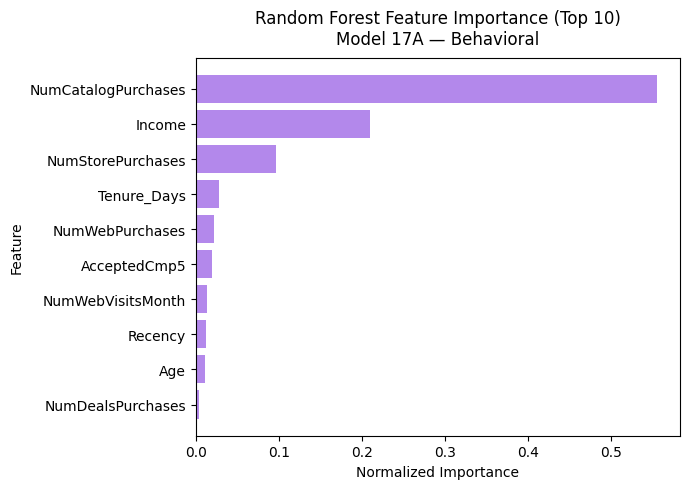

In [237]:
# ============================================================
# 🌲 Feature Importance — Random Forest
# Model 17A — Variant A (Behavioral)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Extract fitted components from best model
# ------------------------------------------------------------
preprocessor_A = best_model.named_steps["preprocessor"]
forest_A = best_model.named_steps["rf"]

# ------------------------------------------------------------
# Feature names AFTER preprocessing
# ------------------------------------------------------------
feature_names_A = preprocessor_A.get_feature_names_out()

# ------------------------------------------------------------
# Feature importances
# ------------------------------------------------------------
importances_A = forest_A.feature_importances_

feat_imp_A = (
    pd.DataFrame({
        "feature": feature_names_A,
        "importance": importances_A
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Normalize importances (sum to 1)
feat_imp_A["importance_norm"] = (
    feat_imp_A["importance"] / feat_imp_A["importance"].sum()
)

# ------------------------------------------------------------
# Bar plot — Top K features
# ------------------------------------------------------------
TOP_K = 10
top_feat_A = feat_imp_A.head(TOP_K).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(
    top_feat_A["feature"],
    top_feat_A["importance_norm"],
    color="#B388EB"
)

plt.title(
    "Random Forest Feature Importance (Top 10)\n"
    "Model 17A — Behavioral",
    pad=10
)
plt.xlabel("Normalized Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


#### 🔹 Variant B — Profile-only feature set

In [238]:
# ============================================================
# Model 17 — Tuned Random Forest
# Variant B: Profile-only feature set
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# Target (NO log for tree models)
# ------------------------------------------------------------
y_train_m17 = y_train
y_test_m17  = y_test

# ------------------------------------------------------------
# Pipeline (USING EXISTING COMPONENTS)
# ------------------------------------------------------------
pipe_rf_m17b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ))
])

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "rf__max_depth": [None, 8, 12, 16],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_rf_m17b,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit (TRAIN ONLY)
# ------------------------------------------------------------
grid.fit(X_train, y_train_m17)

best_model_17b = grid.best_estimator_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model_17b.predict(X_train)
y_test_pred  = best_model_17b.predict(X_test)

r2_train = r2_score(y_train_m17, y_train_pred)
r2_test  = r2_score(y_test_m17, y_test_pred)
mse_train = mean_squared_error(y_train_m17, y_train_pred)
mse_test  = mean_squared_error(y_test_m17, y_test_pred)

forest = best_model_17b.named_steps["rf"]
oob_r2 = forest.oob_score_

# ------------------------------------------------------------
# Feature count (ROBUST)
# ------------------------------------------------------------
X_tmp = tree_preprocessor_B.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
tree_depths = [est.tree_.max_depth for est in forest.estimators_]
leaf_counts = [(est.tree_.children_left == -1).sum() for est in forest.estimators_]

mean_depth  = float(np.mean(tree_depths))
mean_leaves = float(np.mean(leaf_counts))

# ------------------------------------------------------------
# Log
# ------------------------------------------------------------
log_profile_model(
    name="Model 17 — Tuned Random Forest",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=grid.best_score_,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=f"OOB R²={oob_r2:.3f}, GridSearchCV"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("🌲 Model 17 — Tuned Random Forest (Profile-only)")
print(f"Best params:              {grid.best_params_}")
print(f"OOB R²:                   {oob_r2:.3f}")
print(f"R² train:                {r2_train:.3f}")
print(f"R² test:                 {r2_test:.3f}")
print(f"Best CV R² (5-fold):     {grid.best_score_:.3f}")
print(f"MSE train:               {mse_train:.3f}")
print(f"MSE test:                {mse_test:.3f}")
print(f"Mean tree depth:         {mean_depth:.1f}")
print(f"Mean leaf nodes / tree:  {mean_leaves:.1f}")
print(f"Total features used:     {feature_count}")


/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)
/Users/nazilafazeli/Desktop/ML/Customer_Person

🌲 Model 17 — Tuned Random Forest (Profile-only)
Best params:              {'rf__max_depth': 8, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2}
OOB R²:                   0.768
R² train:                0.855
R² test:                 0.725
Best CV R² (5-fold):     0.768
MSE train:               53189.929
MSE test:                95580.507
Mean tree depth:         8.0
Mean leaf nodes / tree:  112.9
Total features used:     15


/Users/nazilafazeli/Desktop/ML/Customer_Personality_Analysis/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


#### 🌲 Feature Importance + Barplot Variant B — Profile-only (Model 17B)

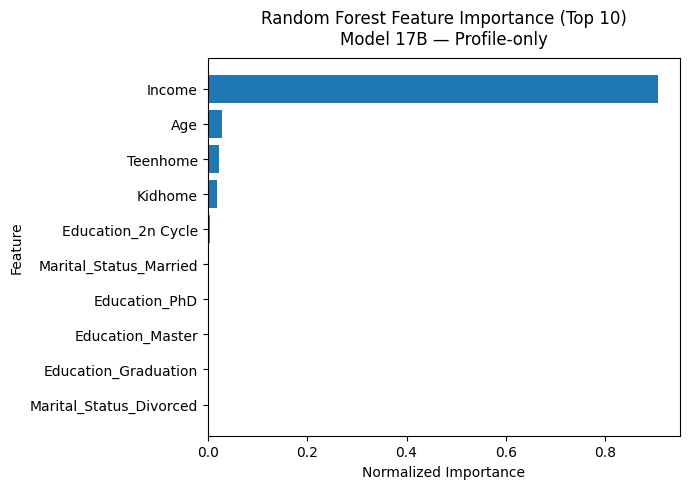

In [240]:
# ============================================================
# 🌲 Feature Importance — Random Forest
# Variant B: Profile-only
# Model 17B
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Get preprocessor & forest from fitted pipeline
# ------------------------------------------------------------
preprocessor_B = best_model_17b.named_steps["preprocessor"]
forest_B = best_model_17b.named_steps["rf"]

# ------------------------------------------------------------
# Feature names & importances
# ------------------------------------------------------------
feature_names_B = preprocessor_B.get_feature_names_out()
importances_B = forest_B.feature_importances_

feat_imp_B = (
    pd.DataFrame({
        "feature": feature_names_B,
        "importance": importances_B
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Normalized importance (for readability)
feat_imp_B["importance_norm"] = (
    feat_imp_B["importance"] / feat_imp_B["importance"].sum()
)

# ------------------------------------------------------------
# Bar plot — Top K features
# ------------------------------------------------------------
TOP_K = 10
top_feat_B = feat_imp_B.head(TOP_K).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(
    top_feat_B["feature"],
    top_feat_B["importance_norm"]
)
plt.title(
    "Random Forest Feature Importance (Top 10)\nModel 17B — Profile-only",
    pad=10
)
plt.xlabel("Normalized Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Model 18 — Gradient Boosting Regressor (Baseline)

#### 🔹 Variant A — Profile + Behavioral feature set

In [241]:
# ============================================================
# Model 18 — Gradient Boosting Regressor
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Target (NO log for tree-based models)
# ------------------------------------------------------------
y_train_m18 = y_train
y_test_m18  = y_test

# ------------------------------------------------------------
# Pipeline (SAME tree pipeline as Models 12–17)
# ------------------------------------------------------------
pipe_gbr_m18a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),
    ("gbr", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=1.0,
        random_state=42
    ))
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_gbr_m18a,
    X_train,          # full raw dataframe
    y_train_m18,
    cv=cv,
    scoring="r2",
    n_jobs=1
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_gbr_m18a.fit(X_train, y_train_m18)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_gbr_m18a.predict(X_train)
y_test_pred  = pipe_gbr_m18a.predict(X_test)

r2_train = r2_score(y_train_m18, y_train_pred)
r2_test  = r2_score(y_test_m18, y_test_pred)

mse_train = mean_squared_error(y_train_m18, y_train_pred)
mse_test  = mean_squared_error(y_test_m18, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust, consistent with tree models)
# ------------------------------------------------------------
X_tmp = tree_preprocessor_A.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 18 — Gradient Boosting",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Baseline Gradient Boosting, same tree pipeline as Models 12–17"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 18 — Gradient Boosting (Behavioral)")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"R² CV    : {r2_cv:.3f}")
print(f"Features : {feature_count}")


Model 18 — Gradient Boosting (Behavioral)
R² test  : 0.877
R² train : 0.938
R² CV    : 0.875
Features : 29


#### 🔹 Variant B — Profile-only feature set

In [242]:
# ============================================================
# Model 18 — Gradient Boosting Regressor
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Target (NO log for tree-based models)
# ------------------------------------------------------------
y_train_m18 = y_train
y_test_m18  = y_test

# ------------------------------------------------------------
# Pipeline (tree-consistent, CORRECT)
# ------------------------------------------------------------
pipe_gbr_m18b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),
    ("gbr", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=1.0,
        random_state=42
    ))
])

# ------------------------------------------------------------
# Cross-validation (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_gbr_m18b,
    X_train,          # full raw dataframe
    y_train_m18,
    cv=cv,
    scoring="r2",
    n_jobs=1
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_gbr_m18b.fit(X_train, y_train_m18)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_gbr_m18b.predict(X_train)
y_test_pred  = pipe_gbr_m18b.predict(X_test)

r2_train = r2_score(y_train_m18, y_train_pred)
r2_test  = r2_score(y_test_m18, y_test_pred)

mse_train = mean_squared_error(y_train_m18, y_train_pred)
mse_test  = mean_squared_error(y_test_m18, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust, consistent)
# ------------------------------------------------------------
X_tmp = tree_preprocessor_B.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_profile_model(
    name="Model 18 — Gradient Boosting",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Baseline Gradient Boosting, profile-only, tree pipeline"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 18 — Gradient Boosting (Profile-only)")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"R² CV    : {r2_cv:.3f}")
print(f"Features : {feature_count}")


Model 18 — Gradient Boosting (Profile-only)
R² test  : 0.737
R² train : 0.827
R² CV    : 0.769
Features : 15


### Model 19 — XGBoost Regressor (Tuned, CV)

#### 🔹 Variant A — Profile + Behavioral feature set

In [243]:
# ============================================================
# Model 19 — XGBoost Regressor
# Variant A: Behavioral feature set
# ============================================================

from xgboost import XGBRegressor

# ------------------------------------------------------------
# Target (NO log for tree-based models)
# ------------------------------------------------------------
y_train_m19 = y_train
y_test_m19  = y_test

# ------------------------------------------------------------
# Pipeline (tree-consistent, CORRECT)
# ------------------------------------------------------------
pipe_xgb_m19a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_A),
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1      # safer with GridSearch
    ))
])

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "xgb__n_estimators": [300, 500],
    "xgb__max_depth": [3, 5],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_xgb_m19a,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=1          # deliberately limited (very heavy model)
)

# ------------------------------------------------------------
# Fit (TRAIN ONLY)
# ------------------------------------------------------------
grid.fit(X_train, y_train_m19)

best_model = grid.best_estimator_
best_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train_m19, y_train_pred)
r2_test  = r2_score(y_test_m19, y_test_pred)

mse_train = mean_squared_error(y_train_m19, y_train_pred)
mse_test  = mean_squared_error(y_test_m19, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust & consistent)
# ------------------------------------------------------------
X_tmp = tree_preprocessor_A.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 19 — XGBoost",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="XGBoost (GridSearchCV), behavioral features, tree pipeline"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 19 — XGBoost (Behavioral)")
print(f"Best params: {grid.best_params_}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"R² CV    : {best_cv:.3f}")
print(f"Features : {feature_count}")


Model 19 — XGBoost (Behavioral)
Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 500, 'xgb__subsample': 0.8}
R² test  : 0.875
R² train : 1.000
R² CV    : 0.890
Features : 29


#### 🔹 Variant B — Profile-only feature set

In [244]:
# ============================================================
# Model 19 — XGBoost Regressor
# Variant B: Profile-only feature set
# ============================================================

from xgboost import XGBRegressor

# ------------------------------------------------------------
# Target (NO log for tree-based models)
# ------------------------------------------------------------
y_train_m19 = y_train
y_test_m19  = y_test

# ------------------------------------------------------------
# Pipeline (tree-consistent, CORRECT)
# ------------------------------------------------------------
pipe_xgb_m19b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", tree_preprocessor_B),
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1          # safer with GridSearch
    ))
])

# ------------------------------------------------------------
# Hyperparameter grid (LIGHT — profile-only)
# ------------------------------------------------------------
param_grid = {
    "xgb__n_estimators": [200, 400],
    "xgb__max_depth": [2, 3],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_xgb_m19b,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=1            # deliberately limited (heavy model)
)

# ------------------------------------------------------------
# Fit (TRAIN ONLY)
# ------------------------------------------------------------
grid.fit(X_train, y_train_m19)

best_model = grid.best_estimator_
best_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train_m19, y_train_pred)
r2_test  = r2_score(y_test_m19, y_test_pred)

mse_train = mean_squared_error(y_train_m19, y_train_pred)
mse_test  = mean_squared_error(y_test_m19, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust & consistent)
# ------------------------------------------------------------
X_tmp = tree_preprocessor_B.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_profile_model(
    name="Model 19 — XGBoost",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="XGBoost (GridSearchCV), profile-only features, tree pipeline"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 19 — XGBoost (Profile-only)")
print(f"Best params: {grid.best_params_}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"R² CV    : {best_cv:.3f}")
print(f"Features : {feature_count}")


Model 19 — XGBoost (Profile-only)
Best params: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
R² test  : 0.732
R² train : 0.824
R² CV    : 0.767
Features : 15


## 5. Kernel-Based Model

In [246]:
# ============================================================
# Feature Groups — Variant A (Behavioral)
# ============================================================

numeric_capped_cols_A = [
    "Income",
    "Age"
]

numeric_scaled_cols_A = [
    "Tenure_Days",
    "Tenure_Months",
    "Recency"
]

numeric_count_cols_A = [
    "Kidhome",
    "Teenhome",
    "FamilySize",
    "TotalPurchases",
    "TotalAccepted"
]

binary_cols_A = [
    "HasChildren",
    "Complain"
]

categorical_cols_A = [
    "Education",
    "Education_Level_Grouped",
    "Marital_Status"
]

campaign_cols_A = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]


In [247]:
# ============================================================
# Feature Groups — Variant B (Profile-only)
# ============================================================

numeric_capped_cols_B = [
    "Income",
    "Age"
]

numeric_scaled_cols_B = []   # ❌ no tenure / recency

numeric_count_cols_B = [
    "Kidhome",
    "Teenhome",
    "FamilySize"
]

binary_cols_B = [
    "HasChildren"
]

categorical_cols_B = [
    "Education",
    "Education_Level_Grouped",
    "Marital_Status"
]

campaign_cols_B = []   # ❌ no campaign info


In [248]:
preprocessor_A = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols_A),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols_A),
        ("num_count",  numeric_count_pipeline,  numeric_count_cols_A),
        ("binary",     "passthrough",           binary_cols_A),
        ("cat",        categorical_pipeline,    categorical_cols_A),
        ("campaign",   "passthrough",           campaign_cols_A),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [250]:
preprocessor_B = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols_B),
        ("num_count",  numeric_count_pipeline,  numeric_count_cols_B),
        ("binary",     "passthrough",           binary_cols_B),
        ("cat",        categorical_pipeline,    categorical_cols_B),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


### Model 20 — SVR (RBF)(Lasso-selected features)

#### 🔹 Variant A — Profile + Behavioral feature set

In [252]:
# ============================================================
# Model 20 — SVR (RBF)
# Variant A: Behavioral (full feature set)
# ============================================================

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Target (log-scale REQUIRED for SVR)
# ------------------------------------------------------------
y_train_m20 = y_train
y_test_m20  = y_test

# ------------------------------------------------------------
# Pipeline (distance-based, CORRECT)
# ------------------------------------------------------------
pipe_svr_m20a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_A),   # ✅ Variant A feature groups
    ("svr", SVR(kernel="rbf"))
])

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "svr__C": [0.1, 1, 10],
    "svr__gamma": ["scale", 0.1, 0.01],
    "svr__epsilon": [0.01, 0.1]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_svr_m20a,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit (TRAIN ONLY)
# ------------------------------------------------------------
grid.fit(X_train, y_train_m20)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train_m20, y_train_pred)
r2_test  = r2_score(y_test_m20, y_test_pred)

mse_train = mean_squared_error(y_train_m20, y_train_pred)
mse_test  = mean_squared_error(y_test_m20, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust & consistent)
# ------------------------------------------------------------
X_tmp = preprocessor_A.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 20 — SVR (RBF)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="SVR with RBF kernel, full behavioral feature set (Variant A)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 20 — SVR (RBF, Behavioral)")
print(f"Best params: {grid.best_params_}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"R² CV    : {r2_cv:.3f}")
print(f"Features : {feature_count}")


Model 20 — SVR (RBF, Behavioral)
Best params: {'svr__C': 10, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
R² test  : 0.694
R² train : 0.708
R² CV    : 0.674
Features : 32


#### 🔹 Variant B — Profile-only feature set

In [254]:
# ============================================================
# Model 20 — SVR (RBF)
# Variant B: Profile-only
# ============================================================

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Target (same logic as Model 20A — NO log)
# ------------------------------------------------------------
y_train_m20 = y_train
y_test_m20  = y_test

# ------------------------------------------------------------
# Pipeline (distance-based, CORRECT & CONSISTENT)
# ------------------------------------------------------------
pipe_svr_m20b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_B),   # ✅ Profile-only feature groups
    ("svr", SVR(kernel="rbf"))
])

# ------------------------------------------------------------
# Hyperparameter grid (same as 20A)
# ------------------------------------------------------------
param_grid = {
    "svr__C": [0.1, 1, 10],
    "svr__gamma": ["scale", 0.1, 0.01],
    "svr__epsilon": [0.01, 0.1]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_svr_m20b,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit (TRAIN ONLY)
# ------------------------------------------------------------
grid.fit(X_train, y_train_m20)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

r2_train = r2_score(y_train_m20, y_train_pred)
r2_test  = r2_score(y_test_m20, y_test_pred)

mse_train = mean_squared_error(y_train_m20, y_train_pred)
mse_test  = mean_squared_error(y_test_m20, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust & consistent)
# ------------------------------------------------------------
X_tmp = preprocessor_B.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)
feature_count = X_tmp.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
log_profile_model(
    name="Model 20 — SVR (RBF)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="SVR with RBF kernel, profile-only feature set (Variant B)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 20 — SVR (RBF, Profile-only)")
print(f"Best params: {grid.best_params_}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")
print(f"R² CV    : {r2_cv:.3f}")
print(f"Features : {feature_count}")


Model 20 — SVR (RBF, Profile-only)
Best params: {'svr__C': 10, 'svr__epsilon': 0.01, 'svr__gamma': 0.1}
R² test  : 0.650
R² train : 0.679
R² CV    : 0.650
Features : 20


### Model 21 — SVR (RBF)(on Polynomial Lasso–selected features)

#### 🔹 Variant A — Profile + Behavioral feature set

In [241]:
# ============================================================
# Model 21 — SVR (RBF)
# Variant A: Polynomial Lasso-selected (Behavioral)
# ============================================================

# ------------------------------------------------------------
# 1) Polynomial feature space (from Model 10A)
# ------------------------------------------------------------
X_train_poly = (
    pipe_lasso_poly_fixed_behavioral
    .named_steps["pre"]
    .transform(X_train_m10_A)
)

X_test_poly = (
    pipe_lasso_poly_fixed_behavioral
    .named_steps["pre"]
    .transform(X_test_m10_A)
)

feature_names_poly = (
    pipe_lasso_poly_fixed_behavioral
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# 2) Select polynomial features kept by Lasso
# ------------------------------------------------------------
coefs = pipe_lasso_poly_fixed_behavioral.named_steps["lasso"].coef_

selected_idx = [i for i, c in enumerate(coefs) if abs(c) > 1e-8]

X_train_sel = X_train_poly[:, selected_idx]
X_test_sel  = X_test_poly[:, selected_idx]

feature_count = len(selected_idx)

y_train_m21 = y_train_log
y_test_m21  = y_test_log

# ------------------------------------------------------------
# 3) Scaling (SVR requires scaling)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

# ------------------------------------------------------------
# 4) SVR + GridSearchCV
# ------------------------------------------------------------
svr = SVR(kernel="rbf")

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    svr,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# 5) Fit
# ------------------------------------------------------------
grid.fit(X_train_scaled, y_train_m21)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# 6) Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred  = best_model.predict(X_test_scaled)

r2_train = r2_score(y_train_m21, y_train_pred)
r2_test  = r2_score(y_test_m21, y_test_pred)
mse_train = mean_squared_error(y_train_m21, y_train_pred)
mse_test  = mean_squared_error(y_test_m21, y_test_pred)

# ------------------------------------------------------------
# 7) Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 21 — SVR (Poly Lasso-selected features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="SVR (RBF) on polynomial features selected by Lasso (Model 10A)"
)

print("Model 21 — SVR (Poly Lasso-selected features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Final feature count: {feature_count}")


Model 21 — SVR (Poly Lasso-selected features)
R² test : 0.965
R² train: 0.966
R² CV   : 0.953
Final feature count: 21


#### 🔹 Variant B — Profile-only feature set

In [253]:
# ============================================================
# Model 21 — SVR (RBF)
# Variant B: Polynomial Lasso-selected (Profile-only)
# ============================================================

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# 1) Polynomial feature space (from Model 10B — FIXED)
# ------------------------------------------------------------
X_train_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .transform(X_train_m10_B)
)

X_test_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .transform(X_test_m10_B)
)

feature_names_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# 2) Select polynomial features kept by Lasso
# ------------------------------------------------------------
coefs = pipe_lasso_poly_fixed_profile.named_steps["lasso"].coef_

selected_idx = np.where(np.abs(coefs) > 1e-8)[0]

X_train_sel = X_train_poly[:, selected_idx]
X_test_sel  = X_test_poly[:, selected_idx]

feature_count = len(selected_idx)

# ------------------------------------------------------------
# 3) Target (NO log — consistent with SVR logic)
# ------------------------------------------------------------
y_train_m21 = y_train
y_test_m21  = y_test

# ------------------------------------------------------------
# 4) Scaling (REQUIRED for SVR)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

# ------------------------------------------------------------
# 5) SVR + GridSearchCV
# ------------------------------------------------------------
svr = SVR(kernel="rbf")

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01],
    "epsilon": [0.01, 0.1]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    svr,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# 6) Fit
# ------------------------------------------------------------
grid.fit(X_train_scaled, y_train_m21)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# 7) Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred  = best_model.predict(X_test_scaled)

r2_train = r2_score(y_train_m21, y_train_pred)
r2_test  = r2_score(y_test_m21, y_test_pred)

mse_train = mean_squared_error(y_train_m21, y_train_pred)
mse_test  = mean_squared_error(y_test_m21, y_test_pred)

# ------------------------------------------------------------
# 8) Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 21 — SVR (Poly Lasso-selected features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="SVR (RBF) on polynomial features selected by Lasso (Model 10B), no log target"
)

print("Model 21 — SVR (Poly Lasso-selected features)")
print(f"Best params        : {grid.best_params_}")
print(f"R² test            : {r2_test:.3f}")
print(f"R² train           : {r2_train:.3f}")
print(f"R² CV              : {r2_cv:.3f}")
print(f"Final feature count: {feature_count}")


NameError: name 'pipe_lasso_poly_fixed_profile' is not defined

In [242]:
# ============================================================
# Model 21 — SVR (RBF)
# Variant B: Polynomial Lasso-selected (Profile-only)
# ============================================================

# ------------------------------------------------------------
# 1) Polynomial feature space (from Model 10B)
# ------------------------------------------------------------
X_train_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .transform(X_train_m10_B)
)

X_test_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .transform(X_test_m10_B)
)

feature_names_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# 2) Select polynomial features kept by Lasso
# ------------------------------------------------------------
coefs = pipe_lasso_poly_fixed_profile.named_steps["lasso"].coef_

selected_idx = [i for i, c in enumerate(coefs) if abs(c) > 1e-8]

X_train_sel = X_train_poly[:, selected_idx]
X_test_sel  = X_test_poly[:, selected_idx]

feature_count = len(selected_idx)

y_train_m21 = y_train_log
y_test_m21  = y_test_log

# ------------------------------------------------------------
# 3) Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

# ------------------------------------------------------------
# 4) SVR + GridSearchCV
# ------------------------------------------------------------
svr = SVR(kernel="rbf")

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    svr,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# 5) Fit
# ------------------------------------------------------------
grid.fit(X_train_scaled, y_train_m21)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# 6) Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred  = best_model.predict(X_test_scaled)

r2_train = r2_score(y_train_m21, y_train_pred)
r2_test  = r2_score(y_test_m21, y_test_pred)
mse_train = mean_squared_error(y_train_m21, y_train_pred)
mse_test  = mean_squared_error(y_test_m21, y_test_pred)

# ------------------------------------------------------------
# 7) Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 21 — SVR (Poly Lasso-selected features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="SVR (RBF) on polynomial features selected by Lasso (Model 10B)"
)

print("Model 21 — SVR (Poly Lasso-selected features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Final feature count: {feature_count}")


Model 21 — SVR (Poly Lasso-selected features)
R² test : 0.750
R² train: 0.762
R² CV   : 0.748
Final feature count: 6


### 📋 Final Summary — Behavioral Regression Models

#### Table 1 — Behavioral Regression Models in Order of Development

In [243]:
# ============================================
# 📋 Regression Models – Behavioral Summary
# ============================================

import pandas as pd

df_behavioral = pd.DataFrame(behavioral_log)

summary_cols = [
    "Model",
    "R²_train",
    "R²_test",
    "R²_CV",
    "MSE_test",
    "MSE_train",
    "Feature_count"
]

df_behavioral = df_behavioral[summary_cols]

print("📊 Behavioral Models Summary:")
display(df_behavioral)


📊 Behavioral Models Summary:


,Model,R²_train,R²_test,R²_CV,MSE_test,MSE_train,Feature_count
0,Model 1 — Linear Regression(Baseline),0.873,0.892,0.865,0.23,0.27,27
1,Model 2 — Linear Regression (EDA-based features),0.861,0.878,0.854,0.26,0.30,21
2,Model 3 — Ridge Regression,0.872,0.891,0.867,0.24,0.28,27
3,Model 4 — LassoCV,0.873,0.892,0.867,0.24,0.28,18
4,Model 5 — LassoCV (Fixed Alpha),0.866,0.884,0.863,0.25,0.29,8
5,Model 6 — Linear Regression (Lasso-selected),0.868,0.889,0.865,0.24,0.28,8
6,Model 7 — Polynomial Linear Regression,0.961,0.900,0.948,0.22,0.08,93
7,Model 8 — Polynomial Ridge Regression,0.961,0.907,0.948,0.20,0.08,93
8,Model 9 — Polynomial LassoCV,0.961,0.909,0.946,0.20,0.08,90
9,Model 10 — Polynomial Lasso (fixed α),0.929,0.938,0.925,0.13,0.15,21


#### Table 2 — Behavioral Models Ranked by Test R² (Color-Coded by Model Family)

📋 behavioral-only Models — Sorted by R²_test


,Model,R²_train,R²_test,R²_CV,MSE_test,MSE_train,Feature_count,model_id,Model_Family
0,Model 19 — XGBoost,0.997,0.966,0.967,0.07,0.01,13,19,4. Ensemble Tree-Based
1,Model 21 — SVR (Poly Lasso-selected features),0.966,0.965,0.953,0.08,0.07,21,21,5. Kernel-Based
2,Model 20 — SVR (RBF on Lasso-selected features),0.973,0.964,0.949,0.08,0.06,8,20,5. Kernel-Based
3,Model 17 — Tuned Random Forest,0.991,0.962,0.960,0.08,0.02,27,17,4. Ensemble Tree-Based
4,Model 18 — Gradient Boosting,0.979,0.961,0.958,0.08,0.05,27,18,4. Ensemble Tree-Based
5,Model 16 — Base Random Forest,0.995,0.961,0.960,0.08,0.01,27,16,4. Ensemble Tree-Based
6,Model 13 — Tuned Regression Tree,0.969,0.950,0.946,0.11,0.07,27,13,3. Decision Tree
7,Model 15 — Regression Tree (Fixed CCP),0.975,0.948,0.936,0.11,0.05,27,15,3. Decision Tree
8,Model 14 — Regression Tree (CCP Pruned),0.975,0.948,0.936,0.11,0.05,27,14,3. Decision Tree
9,Model 11 — Linear Regression (Poly Lasso-selec...,0.946,0.948,0.942,0.11,0.12,21,11,2. Polynomial Regression


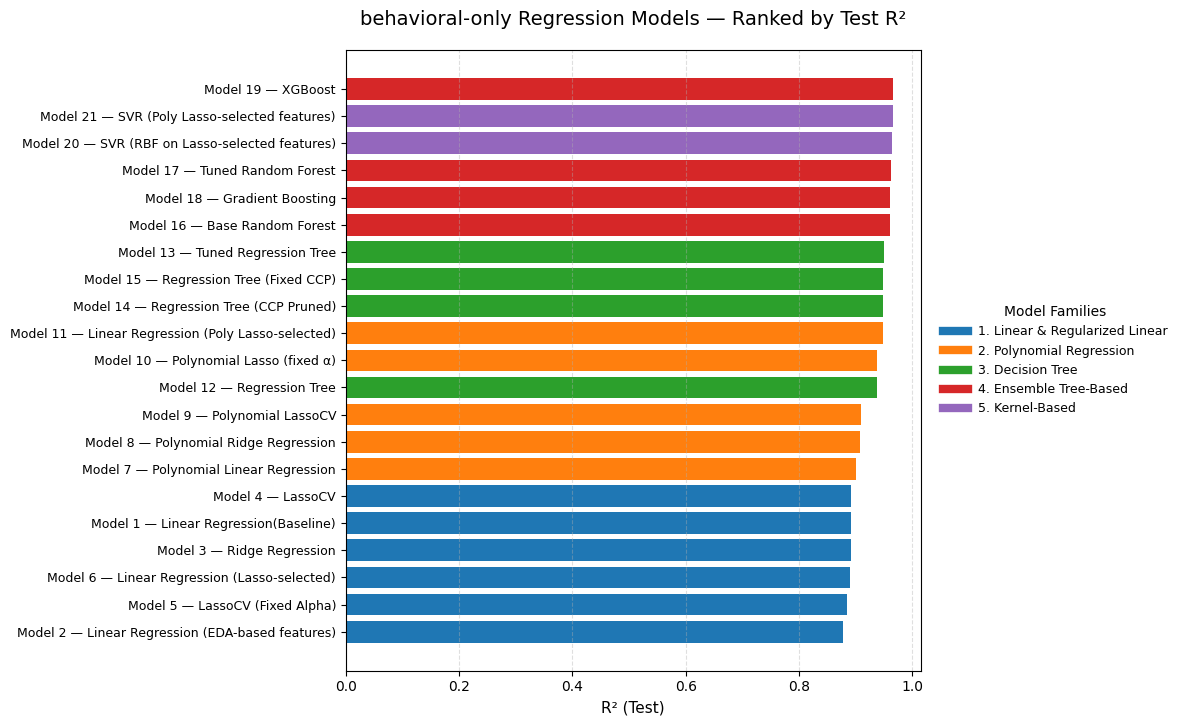

In [244]:

# ------------------------------------------------
# 1) Copy table (safe)
# ------------------------------------------------
df = df_behavioral.copy()

# ------------------------------------------------
# 2) Extract model number from Model name
# ------------------------------------------------
def extract_model_id(model_name):
    match = re.search(r"Model\s+(\d+)", model_name)
    return int(match.group(1)) if match else None

df["model_id"] = df["Model"].apply(extract_model_id)

# ------------------------------------------------
# 3) Assign model family
# ------------------------------------------------
def model_family(model_id):
    if model_id is None:
        return "Other"
    elif 1 <= model_id <= 6:
        return "1. Linear & Regularized Linear"
    elif 7 <= model_id <= 11:
        return "2. Polynomial Regression"
    elif 12 <= model_id <= 15:
        return "3. Decision Tree"
    elif 16 <= model_id <= 19:
        return "4. Ensemble Tree-Based"
    elif 20 <= model_id <= 21:
        return "5. Kernel-Based"
    else:
        return "Other"

df["Model_Family"] = df["model_id"].apply(model_family)

# ------------------------------------------------
# 4) Sort by R²_test
# ------------------------------------------------
df_sorted = (
    df
    .sort_values("R²_test", ascending=False)
    .reset_index(drop=True)
)

print("📋 behavioral-only Models — Sorted by R²_test")
display(df_sorted)

# ------------------------------------------------
# 5) Color mapping
# ------------------------------------------------
family_colors = {
    "1. Linear & Regularized Linear": "#1f77b4",
    "2. Polynomial Regression": "#ff7f0e",
    "3. Decision Tree": "#2ca02c",
    "4. Ensemble Tree-Based": "#d62728",
    "5. Kernel-Based": "#9467bd",
    "Other": "#7f7f7f"
}

bar_colors = df_sorted["Model_Family"].map(family_colors)
# ------------------------------------------------
# 6) Plot (ELEGANT FIX)
# ------------------------------------------------
n_models = len(df_sorted)
fig_height = max(5, n_models * 0.35)

plt.figure(figsize=(12, fig_height))

plt.barh(
    df_sorted["Model"],
    df_sorted["R²_test"],
    color=bar_colors
)

plt.gca().invert_yaxis()

plt.xlabel("R² (Test)", fontsize=11)
plt.ylabel("")
plt.title(
    "behavioral-only Regression Models — Ranked by Test R²",
    fontsize=14,
    pad=18
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.yticks(fontsize=9)
plt.xticks(fontsize=10)

# ------------------------------------------------
# 7) Legend (outside)
# ------------------------------------------------
legend_handles = [
    plt.Line2D([0], [0], color=color, lw=6, label=family)
    for family, color in family_colors.items()
    if family in df_sorted["Model_Family"].values
]

plt.legend(
    handles=legend_handles,
    title="Model Families",
    fontsize=9,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()


### 📋 Final Summary — Profile Regression Models
Models are ranked based on their out-of-sample performance (R² on the test set).
Clear performance differences can be observed across model families, with
ensemble and kernel-based models generally outperforming linear approaches,
while simpler models remain competitive given their interpretability and lower complexity.

#### Table 1 — Profile Regression Models in Order of Development

In [245]:
# ============================================
# 📋 Regression Models – Profile-only Summary
# ============================================

df_profile = pd.DataFrame(profile_log)

summary_cols = [
    "Model",
    "R²_train",
    "R²_test",
    "R²_CV",
    "MSE_test",
    "MSE_train",
    "Feature_count"
]

df_profile = df_profile[summary_cols]

print("📊 Profile-only Models Summary:")
display(df_profile)


📊 Profile-only Models Summary:


,Model,R²_train,R²_test,R²_CV,MSE_test,MSE_train,Feature_count
0,Model 1 — Linear Regression(Baseline),0.660,0.704,0.654,0.64,0.73,13
1,Model 2 — Linear Regression (EDA-based features),0.660,0.705,0.654,0.64,0.73,12
2,Model 3 — Ridge Regression,0.660,0.702,0.655,0.65,0.73,13
3,Model 4 — LassoCV,0.659,0.702,0.657,0.65,0.74,3
4,Model 5 — LassoCV (Fixed Alpha),0.658,0.701,0.657,0.65,0.74,3
5,Model 6 — Linear Regression (Lasso-selected),0.659,0.704,0.658,0.64,0.74,3
6,Model 7 — Polynomial Linear Regression,0.728,0.717,0.717,0.61,0.59,23
7,Model 8 — Polynomial Ridge Regression,0.728,0.718,0.717,0.61,0.59,23
8,Model 9 — Polynomial LassoCV,0.726,0.721,0.717,0.60,0.59,14
9,Model 10 — Polynomial Lasso (fixed α),0.713,0.716,0.709,0.62,0.62,6


#### Table 2 — Profile Regression Models Ranked by Test R²

📋 Profile-only Models — Sorted by R²_test


,Model,R²_train,R²_test,R²_CV,MSE_test,MSE_train,Feature_count,model_id,Model_Family
0,Model 21 — SVR (Poly Lasso-selected features),0.762,0.750,0.748,0.54,0.51,6,21,5. Kernel-Based
1,Model 20 — SVR (RBF on Lasso-selected features),0.761,0.742,0.749,0.56,0.52,4,20,5. Kernel-Based
2,Model 17 — Tuned Random Forest,0.842,0.741,0.739,0.56,0.34,13,17,4. Ensemble Tree-Based
3,Model 19 — XGBoost,0.779,0.740,0.742,0.56,0.48,13,19,4. Ensemble Tree-Based
4,Model 18 — Gradient Boosting,0.808,0.736,0.740,0.57,0.41,13,18,4. Ensemble Tree-Based
5,Model 16 — Base Random Forest,0.963,0.731,0.731,0.58,0.08,13,16,4. Ensemble Tree-Based
6,Model 9 — Polynomial LassoCV,0.726,0.721,0.717,0.60,0.59,14,9,2. Polynomial Regression
7,Model 13 — Tuned Regression Tree,0.755,0.719,0.721,0.61,0.53,13,13,3. Decision Tree
8,Model 8 — Polynomial Ridge Regression,0.728,0.718,0.717,0.61,0.59,23,8,2. Polynomial Regression
9,Model 7 — Polynomial Linear Regression,0.728,0.717,0.717,0.61,0.59,23,7,2. Polynomial Regression


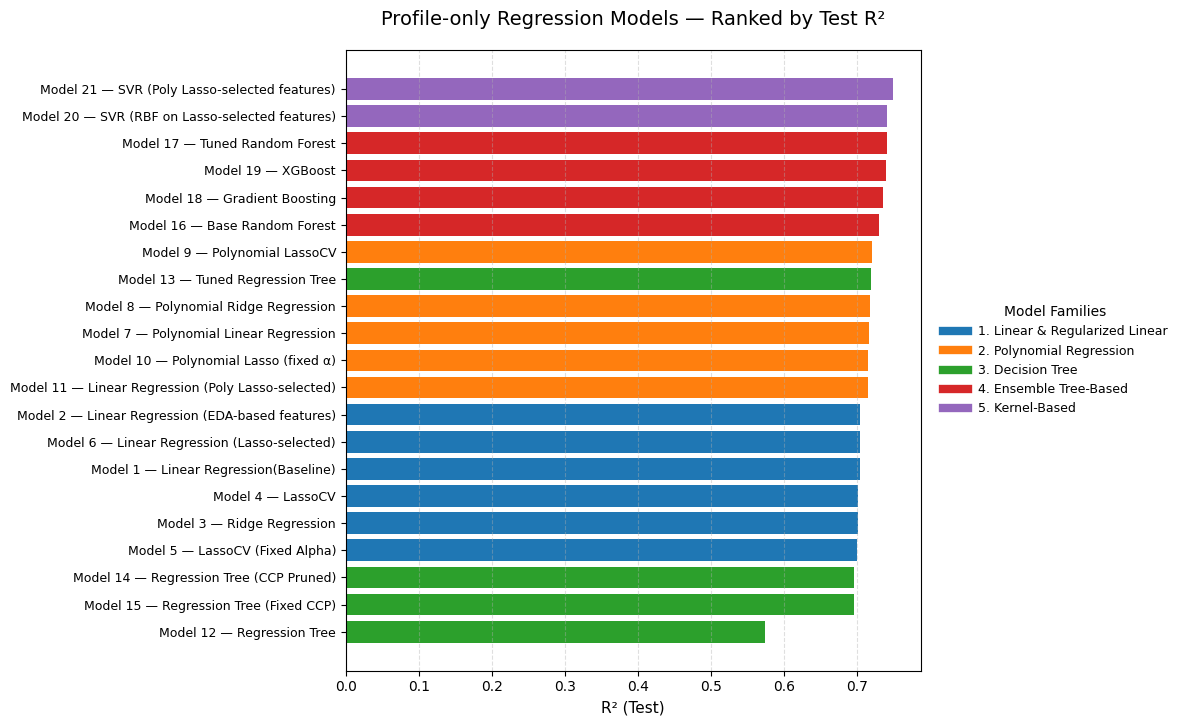

In [246]:

# ------------------------------------------------
# 1) Copy table (safe)
# ------------------------------------------------
df = df_profile.copy()

# ------------------------------------------------
# 2) Extract model number from Model name
# ------------------------------------------------
def extract_model_id(model_name):
    match = re.search(r"Model\s+(\d+)", model_name)
    return int(match.group(1)) if match else None

df["model_id"] = df["Model"].apply(extract_model_id)

# ------------------------------------------------
# 3) Assign model family
# ------------------------------------------------
def model_family(model_id):
    if model_id is None:
        return "Other"
    elif 1 <= model_id <= 6:
        return "1. Linear & Regularized Linear"
    elif 7 <= model_id <= 11:
        return "2. Polynomial Regression"
    elif 12 <= model_id <= 15:
        return "3. Decision Tree"
    elif 16 <= model_id <= 19:
        return "4. Ensemble Tree-Based"
    elif 20 <= model_id <= 21:
        return "5. Kernel-Based"
    else:
        return "Other"

df["Model_Family"] = df["model_id"].apply(model_family)

# ------------------------------------------------
# 4) Sort by R²_test
# ------------------------------------------------
df_sorted = (
    df
    .sort_values("R²_test", ascending=False)
    .reset_index(drop=True)
)

print("📋 Profile-only Models — Sorted by R²_test")
display(df_sorted)

# ------------------------------------------------
# 5) Color mapping
# ------------------------------------------------
family_colors = {
    "1. Linear & Regularized Linear": "#1f77b4",
    "2. Polynomial Regression": "#ff7f0e",
    "3. Decision Tree": "#2ca02c",
    "4. Ensemble Tree-Based": "#d62728",
    "5. Kernel-Based": "#9467bd",
    "Other": "#7f7f7f"
}

bar_colors = df_sorted["Model_Family"].map(family_colors)

# ------------------------------------------------
# 6) Plot (ELEGANT FIX)
# ------------------------------------------------
n_models = len(df_sorted)
fig_height = max(5, n_models * 0.35)

plt.figure(figsize=(12, fig_height))

plt.barh(
    df_sorted["Model"],
    df_sorted["R²_test"],
    color=bar_colors
)

plt.gca().invert_yaxis()

plt.xlabel("R² (Test)", fontsize=11)
plt.ylabel("")
plt.title(
    "Profile-only Regression Models — Ranked by Test R²",
    fontsize=14,
    pad=18
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.yticks(fontsize=9)
plt.xticks(fontsize=10)

# ------------------------------------------------
# 7) Legend (outside)
# ------------------------------------------------
legend_handles = [
    plt.Line2D([0], [0], color=color, lw=6, label=family)
    for family, color in family_colors.items()
    if family in df_sorted["Model_Family"].values
]

plt.legend(
    handles=legend_handles,
    title="Model Families",
    fontsize=9,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()
